/var/folders/w3/86xn56p92g99gx41t7l95w0m0000gp/T/ipykernel_2008/2095490112.py:148: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_means = polar_df.groupby('Tissue').apply(lambda g: np.average(g['deviation_degrees'], weights=g['r']) if g['r'].sum() > 0 else np.mean(g['deviation_degrees'])).reset_index(name='mean_acute_angle')
/var/folders/w3/86xn56p92g99gx41t7l95w0m0000gp/T/ipykernel_2008/2095490112.py:148: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping colum

Saved: /Volumes/Extreme SSD/Work/SOKs/TIFFS_publication/Fig SX_emergence-cellular/polarisation/script/figures/young_LRP_polar_plots_norm-per-tissue-sample.svg


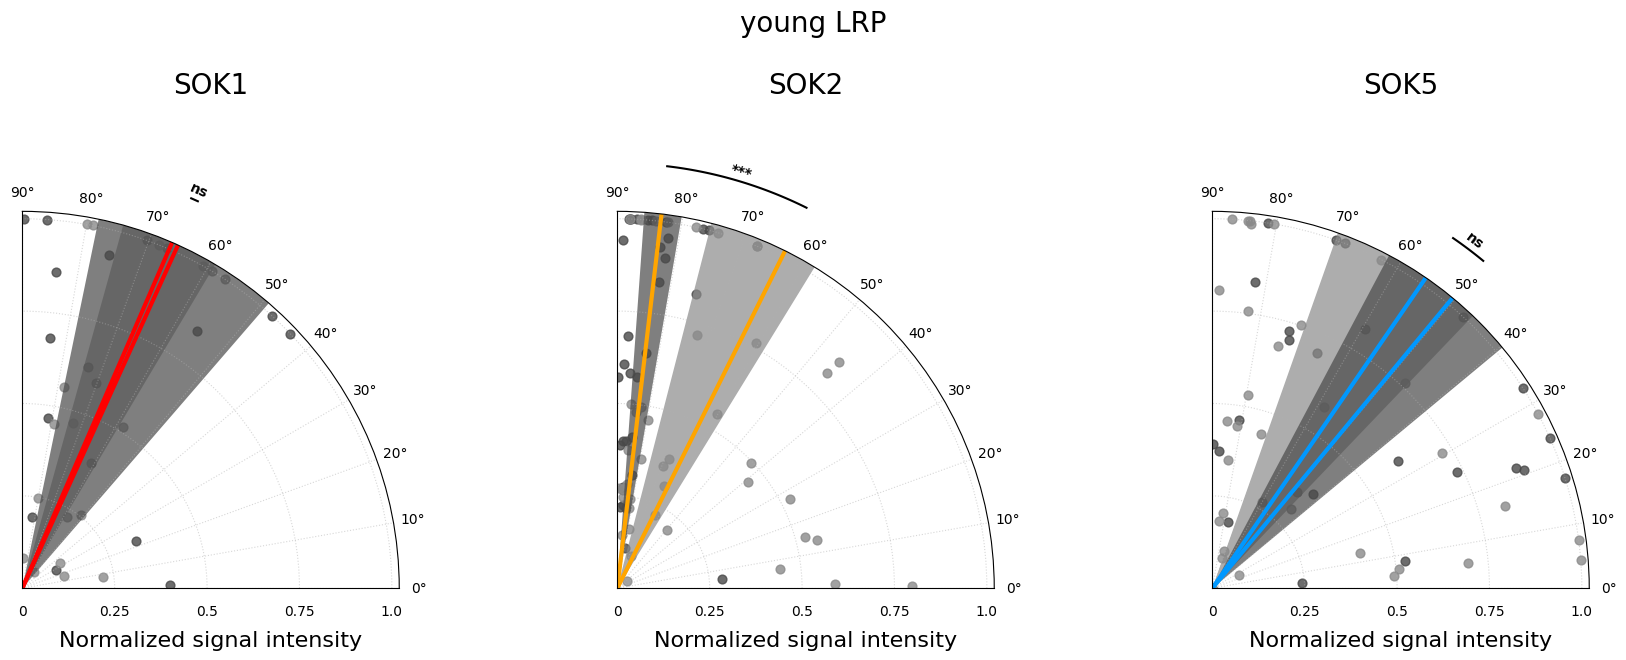

/var/folders/w3/86xn56p92g99gx41t7l95w0m0000gp/T/ipykernel_2008/2095490112.py:148: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_means = polar_df.groupby('Tissue').apply(lambda g: np.average(g['deviation_degrees'], weights=g['r']) if g['r'].sum() > 0 else np.mean(g['deviation_degrees'])).reset_index(name='mean_acute_angle')
/var/folders/w3/86xn56p92g99gx41t7l95w0m0000gp/T/ipykernel_2008/2095490112.py:148: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping colum

Saved: /Volumes/Extreme SSD/Work/SOKs/TIFFS_publication/Fig SX_emergence-cellular/polarisation/script/figures/young_emerged_polar_plots_norm-per-tissue-sample.svg


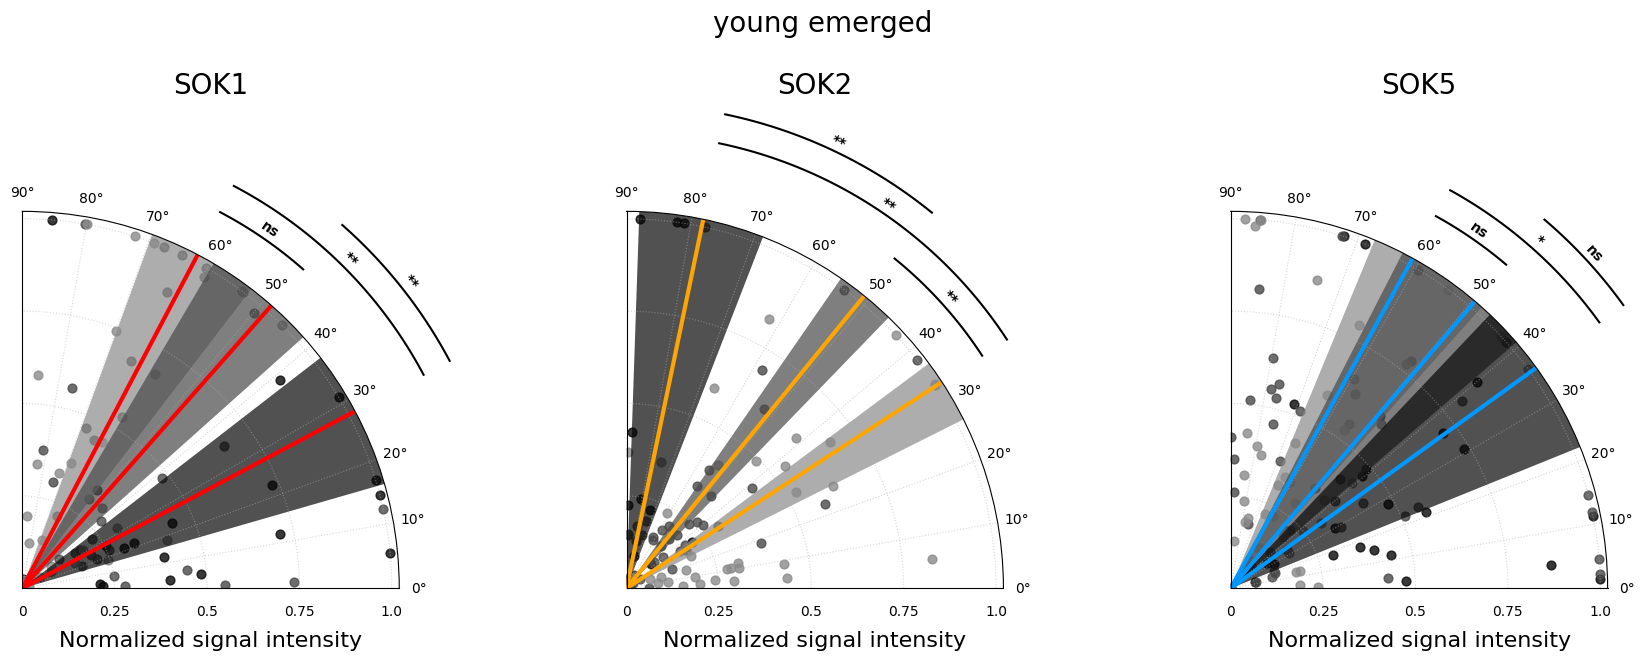

/var/folders/w3/86xn56p92g99gx41t7l95w0m0000gp/T/ipykernel_2008/2095490112.py:148: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_means = polar_df.groupby('Tissue').apply(lambda g: np.average(g['deviation_degrees'], weights=g['r']) if g['r'].sum() > 0 else np.mean(g['deviation_degrees'])).reset_index(name='mean_acute_angle')
/var/folders/w3/86xn56p92g99gx41t7l95w0m0000gp/T/ipykernel_2008/2095490112.py:148: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping colum

Saved: /Volumes/Extreme SSD/Work/SOKs/TIFFS_publication/Fig SX_emergence-cellular/polarisation/script/figures/mature_roots_polar_plots_norm-per-tissue-sample.svg


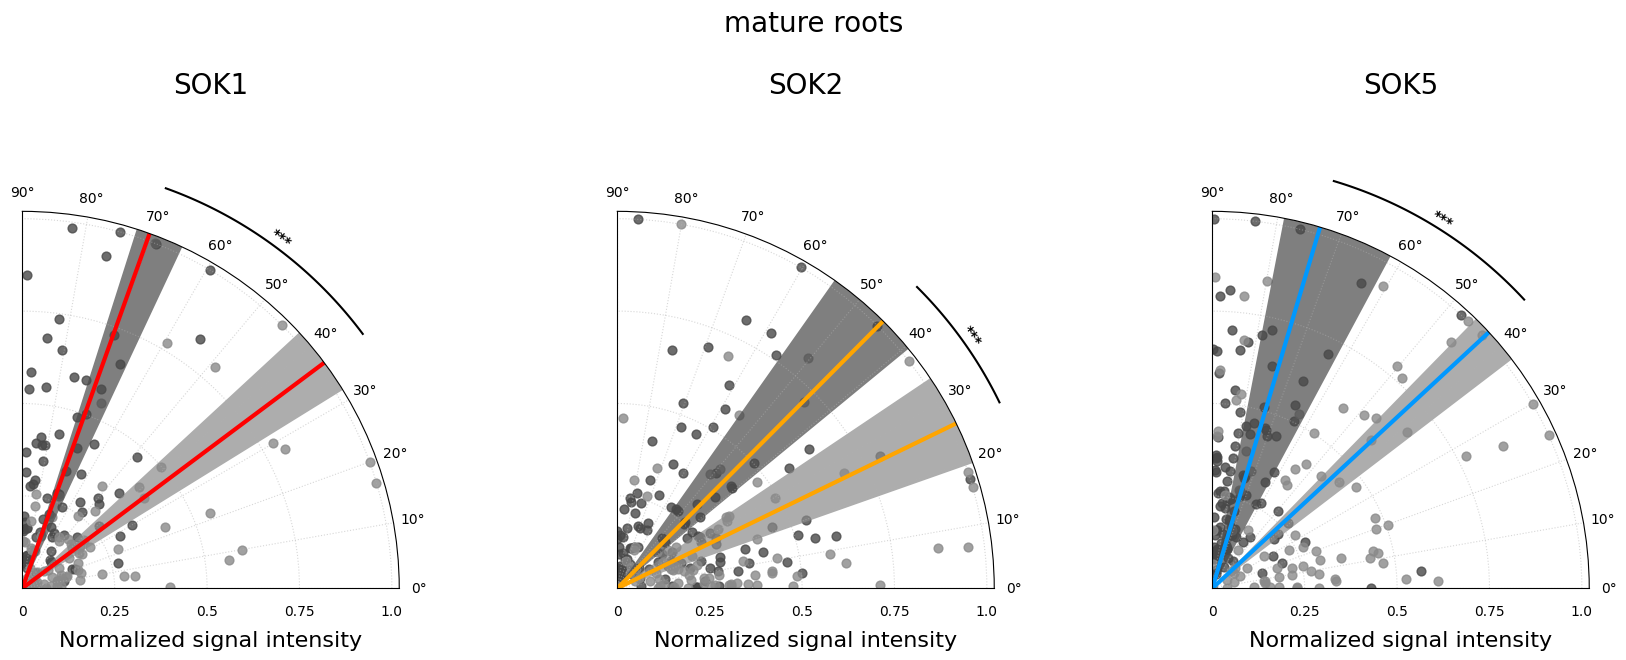

In [1]:
# Combined polar plots for SOK1, SOK2, and SOK5
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

sok_base = Path(r"/Volumes/Extreme SSD/Work/SOKs/TIFFS_publication/Fig SX_emergence-cellular/polarisation/script")
sok_list = ['SOK1', 'SOK2', 'SOK5']
# Minimal color palette (matches earlier cells)
colors = {'A': "#070707", 'G': "#494949", 'V': "#8a8a8a"}

# Helper for bootstrap and significance annotation
from itertools import combinations

# ROOT-LEVEL BOOTSTRAP (correct for hierarchical data)
def bootstrap_root_level_weighted_means(df, n_boot=2000):
    """
    Collapse each root to a single weighted mean, then bootstrap at root level only.
    This gives correct N = number of roots (not number of cells).
    """
    roots = df['source_file'].unique()
    if len(roots) < 2:
        # Degenerate case: not enough roots for inference
        mean_val = np.average(df['deviation_degrees'], weights=df['r']) if df['r'].sum() > 0 else np.mean(df['deviation_degrees'])
        return np.array([mean_val] * n_boot)
    
    # Collapse each root to single weighted mean
    root_means = []
    for root in roots:
        root_data = df[df['source_file'] == root]
        angles = root_data['deviation_degrees'].values
        weights = root_data['r'].values
        mean = np.average(angles, weights=weights) if weights.sum() > 0 else np.mean(angles)
        root_means.append(mean)
    
    # Bootstrap at root level only
    boot_means = np.array([
        np.mean(np.random.choice(root_means, size=len(root_means), replace=True))
        for _ in range(n_boot)
    ])
    return boot_means

def bootstrap_root_level_weighted_diffs(df, tissue_a, tissue_b, n_boot=2000):
    """
    Compare two tissues by collapsing each root to weighted means first,
    then bootstrapping at root level only.
    """
    # Filter to tissues and find common roots
    roots_a = set(df.loc[df['Tissue'] == tissue_a, 'source_file'].unique())
    roots_b = set(df.loc[df['Tissue'] == tissue_b, 'source_file'].unique())
    common_roots = sorted(roots_a.intersection(roots_b))
    
    if not common_roots or len(common_roots) < 2:
        return np.array([])
    
    # Collapse each root to weighted means for each tissue
    root_means_a = []
    root_means_b = []
    
    for root in common_roots:
        root_a = df[(df['source_file'] == root) & (df['Tissue'] == tissue_a)]
        root_b = df[(df['source_file'] == root) & (df['Tissue'] == tissue_b)]
        
        if root_a.empty or root_b.empty:
            continue
        
        mean_a = np.average(root_a['deviation_degrees'], weights=root_a['r']) if root_a['r'].sum() > 0 else np.mean(root_a['deviation_degrees'])
        mean_b = np.average(root_b['deviation_degrees'], weights=root_b['r']) if root_b['r'].sum() > 0 else np.mean(root_b['deviation_degrees'])
        
        root_means_a.append(mean_a)
        root_means_b.append(mean_b)
    
    if not root_means_a or not root_means_b:
        return np.array([])
    
    # Bootstrap at root level only
    boot_diffs = np.array([
        np.mean(np.random.choice(root_means_a, size=len(root_means_a), replace=True)) -
        np.mean(np.random.choice(root_means_b, size=len(root_means_b), replace=True))
        for _ in range(n_boot)
    ])
    return boot_diffs
      
def p_value_to_stars(p):
    if p < 0.0001:
        return '****'
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    return 'ns'


plot_folders = ["young LRP", "young emerged", "mature roots"]
mean_line_colors = {'SOK1': 'red', 'SOK2': 'orange', 'SOK5': '#0098ff'}
ci_r_max = 1.02

tissue_order = ['V', 'G', 'A']

for plot_folder in plot_folders:
    fig, axs = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': 'polar'})
    fig.suptitle(plot_folder, fontsize=20, y=1.05)

    for ax, sok in zip(axs, sok_list):
        sok_folder = sok_base / sok
        csv_folder = sok_folder / plot_folder
        if not csv_folder.exists():
            print(f"No folder {csv_folder} for {sok}")
            ax.set_visible(False)
            continue

        # Load and Filter Data
        polarisation_files = sorted(csv_folder.glob("polarisation*.csv"))
        if not polarisation_files:
            ax.set_visible(False); continue
            
        polar_df = pd.concat((pd.read_csv(f).assign(source_file=f.name) for f in polarisation_files), ignore_index=True)
        
        # --- UPDATED FILTERING LOGIC ---
        if plot_folder == "young emerged":
            # Show all three tissues (V, G, A) for this specific folder
            polar_df = polar_df[polar_df['Tissue'].isin(['V', 'G', 'A'])].copy()
            current_order = ['V', 'G', 'A']
            if 'Specific tissue' in polar_df.columns:
                polar_df = polar_df[polar_df['Specific tissue'] != 'E'].copy()
        else:
            # Standard filtering for others
            polar_df = polar_df[polar_df['Tissue'].isin(['G', 'V'])].copy()
            current_order = ['V', 'G', 'A']
            if 'Specific tissue' in polar_df.columns:
                    polar_df = polar_df[polar_df['Specific tissue'] != 'E'].copy()
        # -------------------------------
            
        if polar_df.empty: 
            ax.set_visible(False); continue

        polar_df['deviation_degrees'] = np.degrees(np.arctan2(np.abs(polar_df['yMax']), np.abs(polar_df['xMax'])))
        polar_df['theta'] = np.radians(polar_df['deviation_degrees'])
        polar_df['r'] = polar_df.groupby(['source_file', 'Tissue'])['signalMax'].transform(
            lambda x: x / x.max() if x.max() != 0 else 0
        )

        for tissue, group in polar_df.groupby('Tissue'):
            ax.scatter(group['theta'], group['r'], c=colors.get(tissue, '#000000'), label=f"Tissue {tissue}", alpha=0.8, s=40)

        weighted_means = polar_df.groupby('Tissue').apply(lambda g: np.average(g['deviation_degrees'], weights=g['r']) if g['r'].sum() > 0 else np.mean(g['deviation_degrees'])).reset_index(name='mean_acute_angle')
        present_tissues = [t for t in tissue_order if t in weighted_means['Tissue'].values]
        cis_local = {}
        bootstrap_reps = {}
        for tissue, group in polar_df.groupby('Tissue'):
            boot = bootstrap_root_level_weighted_means(group, n_boot=2000)
            mean = np.average(group['deviation_degrees'], weights=group['r']) if group['r'].sum() > 0 else np.mean(group['deviation_degrees'])
            if len(boot):
                lo, hi = np.percentile(boot, [2.5, 97.5])
            else:
                lo, hi = mean, mean
            cis_local[tissue] = (lo, hi)
            bootstrap_reps[tissue] = boot
        weighted_means['ci_lo'] = weighted_means['Tissue'].map(lambda t: cis_local[t][0])
        weighted_means['ci_hi'] = weighted_means['Tissue'].map(lambda t: cis_local[t][1])
        
        pairwise_results = []
        # Get all possible combinations (e.g., V-G, V-A, G-A)
        combos = list(combinations(present_tissues, 2))
        num_comparisons = len(combos)
        
        for a, b in combos:
            diffs = bootstrap_root_level_weighted_diffs(polar_df, a, b, n_boot=2000)
            if len(diffs):
                tail_ge = (np.sum(diffs >= 0) + 1) / (len(diffs) + 1)
                tail_le = (np.sum(diffs <= 0) + 1) / (len(diffs) + 1)
                p_raw = min(2 * min(tail_ge, tail_le), 1.0)
                
                # Apply Bonferroni correction
                p_adjusted = min(p_raw * num_comparisons, 1.0)
                
                pairwise_results.append((a, b, p_adjusted))

        mean_angle_map = {}
        for tissue in present_tissues:
            mean_angle = float(weighted_means.loc[weighted_means['Tissue'] == tissue, 'mean_acute_angle'].iloc[0])
            lo_angle = float(weighted_means.loc[weighted_means['Tissue'] == tissue, 'ci_lo'].iloc[0])
            hi_angle = float(weighted_means.loc[weighted_means['Tissue'] == tissue, 'ci_hi'].iloc[0])

            mean_angle_map[tissue] = mean_angle
            theta_mean = np.radians(mean_angle)
            theta_lo = np.radians(lo_angle)
            theta_hi = np.radians(hi_angle)
            ci_color = colors.get(tissue, '#000000')
            mean_color = mean_line_colors.get(sok, '#000000')

            width = theta_hi - theta_lo
            if width < 0:
                width += 2 * np.pi
            ax.bar((theta_lo + width/2), ci_r_max, width=width, bottom=0.0,
                   color=ci_color, alpha=0.7, edgecolor='none', align='center')
            ax.plot([theta_mean, theta_mean], [0, ci_r_max], color=mean_color, linewidth=3, solid_capstyle='butt')

        outer_offset = 0.13
        line_gap = 0.08
        for idx, (a, b, p_boot) in enumerate(pairwise_results):
            if a not in mean_angle_map or b not in mean_angle_map:
                continue
            theta_a = np.radians(mean_angle_map[a])
            theta_b = np.radians(mean_angle_map[b])
            theta_start, theta_end = sorted([theta_a, theta_b])
            arc_r = ci_r_max + outer_offset + idx * line_gap
            arc_theta = np.linspace(theta_start, theta_end, 120)
            ax.plot(arc_theta, np.full_like(arc_theta, arc_r), color='black', lw=1.5, clip_on=False)
            mid_theta = (theta_start + theta_end) / 2
            rotation_angle = np.degrees(mid_theta) + 90
            if rotation_angle > 90:
                rotation_angle -= 180
            ax.text(mid_theta, arc_r + 0.01,
                    p_value_to_stars(p_boot), ha='center', va='bottom', fontsize=10,
                    fontweight='bold', clip_on=False, rotation=rotation_angle, rotation_mode='anchor')

        ax.set_thetamin(0)
        ax.set_thetamax(90)
        ax.set_theta_zero_location("E")
        ax.set_theta_direction(1)
        ax.set_ylim(0, 1.02)
        ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
        ax.set_yticklabels(['0', '0.25', '0.5', '0.75', '1.0'], fontsize=10)
        ax.tick_params(axis='y', pad=8)
        ax.set_xlabel('Normalized signal intensity', fontsize=16, labelpad=25)
        ax.set_title(f"{sok}", fontsize=20, pad=85)
        ax.grid(True, linestyle=':', alpha=0.5)

    output_dir = sok_base / "figures"
    output_dir.mkdir(exist_ok=True)

    filename = output_dir / f"{plot_folder.replace(' ', '_')}_polar_plots_norm-per-tissue-sample.svg"
    plt.savefig(filename, format='svg', bbox_inches='tight')
    print(f"Saved: {filename}")

    plt.tight_layout()
    plt.show()


/var/folders/w3/86xn56p92g99gx41t7l95w0m0000gp/T/ipykernel_2008/4252507759.py:176: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_means = polar_df.groupby('Tissue').apply(
/var/folders/w3/86xn56p92g99gx41t7l95w0m0000gp/T/ipykernel_2008/4252507759.py:176: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_means = polar_df.groupby('Tissue').apply(
/var/folders/w3/86xn56p92g99gx41t7l95w0m0000gp/T/ipykernel_2


CROSS-STAGE STATISTICAL COMPARISONS — ROOT-LEVEL BOOTSTRAP

SOK1:
--------------------------------------------------------------------------------
  Tissue V:
    young LRP vs young emerged: N roots 6 vs 4 | diff=+5.48° [-6.50, 17.29] | p=0.3698 → p_adj=1.0000 [ns]
    young emerged vs mature roots: N roots 4 vs 4 | diff=+24.01° [13.41, 34.90] | p=0.0010 → p_adj=0.0030 [**]
    young LRP vs mature roots: N roots 6 vs 4 | diff=+29.55° [20.57, 38.68] | p=0.0010 → p_adj=0.0030 [**]
  Tissue G:
    young LRP vs young emerged: N roots 6 vs 6 | diff=+14.27° [-3.86, 31.19] | p=0.1249 → p_adj=0.3748 [ns]
    young emerged vs mature roots: N roots 6 vs 3 | diff=-18.41° [-28.30, -8.99] | p=0.0010 → p_adj=0.0030 [**]
    young LRP vs mature roots: N roots 6 vs 3 | diff=-5.09° [-19.93, 9.68] | p=0.5297 → p_adj=1.0000 [ns]

SOK2:
--------------------------------------------------------------------------------
  Tissue V:
    young LRP vs young emerged: N roots 9 vs 3 | diff=+33.63° [23.75, 44.14] 

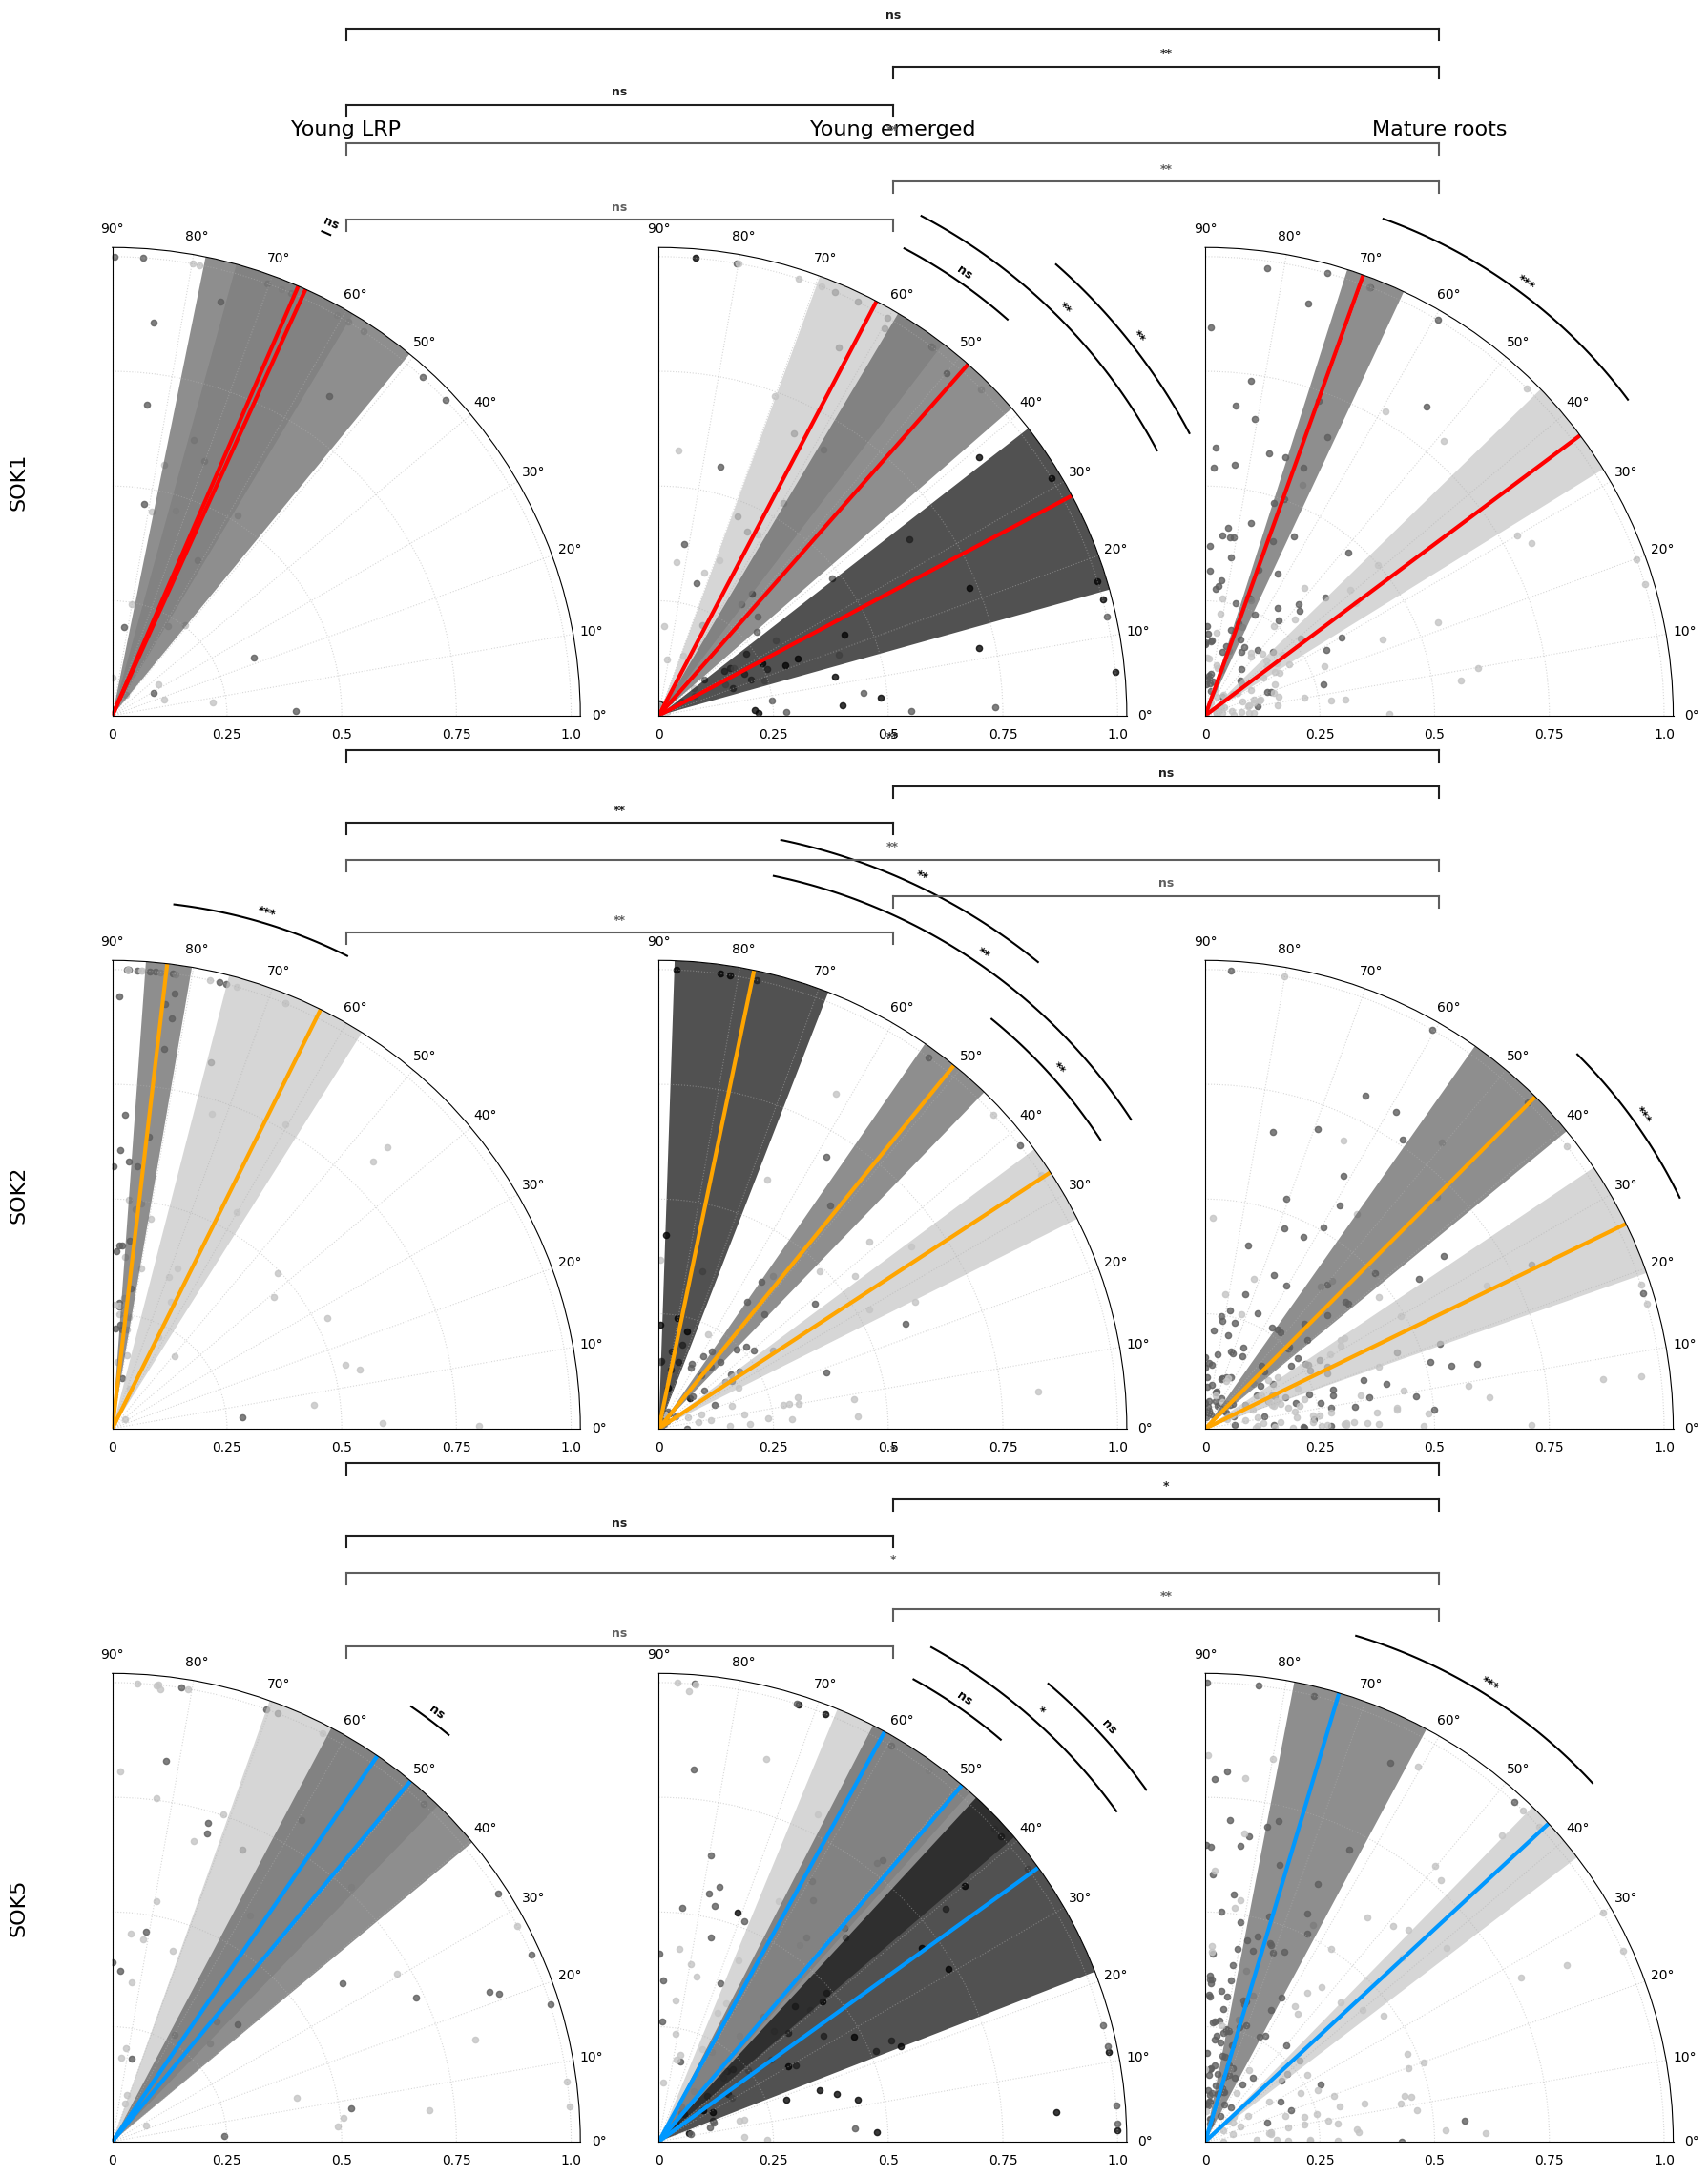

In [2]:
# 3x3 combined figure with cross-stage statistics (ROOT-LEVEL BOOTSTRAP)
# Rows: SOK1, SOK2, SOK5 | Columns: young LRP, young emerged, mature roots
import matplotlib.lines as mlines
from itertools import combinations

sok_base = Path(r"/Volumes/Extreme SSD/Work/SOKs/TIFFS_publication/Fig SX_emergence-cellular/polarisation/script")
sok_list = ['SOK1', 'SOK2', 'SOK5']
col_folders = ['young LRP', 'young emerged', 'mature roots']
colors = {'A': "#070707", 'G': "#5F5F5F", 'V': "#c5c5c5"}
mean_line_colors = {'SOK1': 'red', 'SOK2': 'orange', 'SOK5': '#0098ff'}
tissue_order = ['V', 'G', 'A']
ci_r_max = 1.02
col_titles = ['Young LRP', 'Young emerged', 'Mature roots']

# Colors for cross-stage brackets (tissue-coded)
bracket_tissue_colors = {'V': "#5E5E5E", 'G': "#1F1F1F"}

# ROOT-LEVEL BOOTSTRAP FUNCTIONS
def bootstrap_root_level_weighted_means(df, n_boot=2000):
    """
    Collapse each root to a single weighted mean, then bootstrap at root level only.
    This gives correct N = number of roots (not number of cells).
    """
    roots = df['source_file'].unique()
    if len(roots) < 2:
        mean_val = np.average(df['deviation_degrees'], weights=df['r']) if df['r'].sum() > 0 else np.mean(df['deviation_degrees'])
        return np.array([mean_val] * n_boot)
    
    root_means = []
    for root in roots:
        root_data = df[df['source_file'] == root]
        angles = root_data['deviation_degrees'].values
        weights = root_data['r'].values
        mean = np.average(angles, weights=weights) if weights.sum() > 0 else np.mean(angles)
        root_means.append(mean)
    
    boot_means = np.array([
        np.mean(np.random.choice(root_means, size=len(root_means), replace=True))
        for _ in range(n_boot)
    ])
    return boot_means

def bootstrap_root_level_weighted_diffs(df, tissue_a, tissue_b, n_boot=2000):
    """
    Compare two tissues by collapsing each root to weighted means first,
    then bootstrapping at root level only.
    """
    roots_a = set(df.loc[df['Tissue'] == tissue_a, 'source_file'].unique())
    roots_b = set(df.loc[df['Tissue'] == tissue_b, 'source_file'].unique())
    common_roots = sorted(roots_a.intersection(roots_b))
    
    if not common_roots or len(common_roots) < 2:
        return np.array([])
    
    root_means_a = []
    root_means_b = []
    
    for root in common_roots:
        root_a = df[(df['source_file'] == root) & (df['Tissue'] == tissue_a)]
        root_b = df[(df['source_file'] == root) & (df['Tissue'] == tissue_b)]
        
        if root_a.empty or root_b.empty:
            continue
        
        mean_a = np.average(root_a['deviation_degrees'], weights=root_a['r']) if root_a['r'].sum() > 0 else np.mean(root_a['deviation_degrees'])
        mean_b = np.average(root_b['deviation_degrees'], weights=root_b['r']) if root_b['r'].sum() > 0 else np.mean(root_b['deviation_degrees'])
        
        root_means_a.append(mean_a)
        root_means_b.append(mean_b)
    
    if not root_means_a or not root_means_b:
        return np.array([])
    
    boot_diffs = np.array([
        np.mean(np.random.choice(root_means_a, size=len(root_means_a), replace=True)) -
        np.mean(np.random.choice(root_means_b, size=len(root_means_b), replace=True))
        for _ in range(n_boot)
    ])
    return boot_diffs

def p_value_to_stars(p):
    if p < 0.0001:
        return '****'
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    return 'ns'

def draw_figure_bracket(fig, x1, x2, y, text, color='black', lw=1.5, fontsize=9):
    """Draw a horizontal significance bracket between two x positions at height y in figure space."""
    tick_h = 0.005
    fig.add_artist(mlines.Line2D([x1, x2], [y, y], transform=fig.transFigure,
                                  color=color, lw=lw, clip_on=False))
    for x in [x1, x2]:
        fig.add_artist(mlines.Line2D([x, x], [y - tick_h, y], transform=fig.transFigure,
                                      color=color, lw=lw, clip_on=False))
    fig.text((x1 + x2) / 2, y + 0.003, text, ha='center', va='bottom',
             fontsize=fontsize, fontweight='bold', color=color,
             transform=fig.transFigure)

def bootstrap_root_level_comparison(stage_a_dfs, stage_b_dfs, n_boot=2000):
    """Collapse each root to single weighted mean, then bootstrap at root level only."""
    def root_mean(root_df):
        w = root_df['r'].values
        return np.average(root_df['deviation_degrees'], weights=w) if w.sum() > 0 else np.mean(root_df['deviation_degrees'])

    means_a = [root_mean(df) for df in stage_a_dfs if len(df) > 0]
    means_b = [root_mean(df) for df in stage_b_dfs if len(df) > 0]

    if len(means_a) == 0 or len(means_b) == 0:
        return np.array([])

    boot_diffs = np.empty(n_boot)
    for i in range(n_boot):
        boot_diffs[i] = (np.mean(np.random.choice(means_a, size=len(means_a), replace=True)) -
                         np.mean(np.random.choice(means_b, size=len(means_b), replace=True)))
    return boot_diffs

# Storage for cross-stage comparisons: (row_idx, col_idx, tissue) -> processed df
all_stage_dfs = {}

fig, axs = plt.subplots(3, 3, figsize=(18, 24), subplot_kw={'projection': 'polar'})

for row_idx, sok in enumerate(sok_list):
    for col_idx, plot_folder in enumerate(col_folders):
        ax = axs[row_idx, col_idx]

        sok_folder = sok_base / sok
        csv_folder = sok_folder / plot_folder

        if not csv_folder.exists():
            ax.set_visible(False)
            continue

        polarisation_files = sorted(csv_folder.glob("polarisation*.csv"))
        if not polarisation_files:
            ax.set_visible(False)
            continue

        polar_df = pd.concat(
            (pd.read_csv(f).assign(source_file=f.name) for f in polarisation_files),
            ignore_index=True
        )

        if plot_folder == "young emerged":
            polar_df = polar_df[polar_df['Tissue'].isin(['V', 'G', 'A'])].copy()
        else:
            polar_df = polar_df[polar_df['Tissue'].isin(['G', 'V'])].copy()

        if 'Specific tissue' in polar_df.columns:
            polar_df = polar_df[polar_df['Specific tissue'] != 'E'].copy()

        if polar_df.empty:
            ax.set_visible(False)
            continue

        polar_df['deviation_degrees'] = np.degrees(np.arctan2(np.abs(polar_df['yMax']), np.abs(polar_df['xMax'])))
        polar_df['theta'] = np.radians(polar_df['deviation_degrees'])
        polar_df['r'] = polar_df.groupby(['source_file', 'Tissue'])['signalMax'].transform(
            lambda x: x / x.max() if x.max() != 0 else 0
        )

        # Store per-tissue dataframes for cross-stage comparison
        for tissue in polar_df['Tissue'].unique():
            all_stage_dfs[(row_idx, col_idx, tissue)] = (
                polar_df[polar_df['Tissue'] == tissue][['deviation_degrees', 'r', 'source_file']].copy()
            )

        for tissue, group in polar_df.groupby('Tissue'):
            ax.scatter(group['theta'], group['r'], c=colors.get(tissue, '#000000'),
                       label=f"Tissue {tissue}", alpha=0.8, s=20)

        weighted_means = polar_df.groupby('Tissue').apply(
            lambda g: np.average(g['deviation_degrees'], weights=g['r']) if g['r'].sum() > 0 else np.mean(g['deviation_degrees'])
        ).reset_index(name='mean_acute_angle')

        present_tissues = [t for t in tissue_order if t in weighted_means['Tissue'].values]
        cis_local = {}
        bootstrap_reps = {}
        for tissue, group in polar_df.groupby('Tissue'):
            boot = bootstrap_root_level_weighted_means(group, n_boot=2000)
            if len(boot):
                lo, hi = np.percentile(boot, [2.5, 97.5])
            else:
                mean = np.average(group['deviation_degrees'], weights=group['r']) if group['r'].sum() > 0 else np.mean(group['deviation_degrees'])
                lo, hi = mean, mean
            cis_local[tissue] = (lo, hi)
            bootstrap_reps[tissue] = boot

        weighted_means['ci_lo'] = weighted_means['Tissue'].map(lambda t: cis_local[t][0])
        weighted_means['ci_hi'] = weighted_means['Tissue'].map(lambda t: cis_local[t][1])

        combos = list(combinations(present_tissues, 2))
        num_comparisons = len(combos)
        pairwise_results = []
        for a, b in combos:
            diffs = bootstrap_root_level_weighted_diffs(polar_df, a, b, n_boot=2000)
            if len(diffs):
                tail_ge = (np.sum(diffs >= 0) + 1) / (len(diffs) + 1)
                tail_le = (np.sum(diffs <= 0) + 1) / (len(diffs) + 1)
                p_raw = min(2 * min(tail_ge, tail_le), 1.0)
                p_adjusted = min(p_raw * num_comparisons, 1.0)
                pairwise_results.append((a, b, p_adjusted))

        mean_angle_map = {}
        for tissue in present_tissues:
            mean_angle = float(weighted_means.loc[weighted_means['Tissue'] == tissue, 'mean_acute_angle'].iloc[0])
            lo_angle = float(weighted_means.loc[weighted_means['Tissue'] == tissue, 'ci_lo'].iloc[0])
            hi_angle = float(weighted_means.loc[weighted_means['Tissue'] == tissue, 'ci_hi'].iloc[0])

            mean_angle_map[tissue] = mean_angle
            theta_mean = np.radians(mean_angle)
            theta_lo = np.radians(lo_angle)
            theta_hi = np.radians(hi_angle)
            ci_color = colors.get(tissue, '#000000')
            mean_color = mean_line_colors.get(sok, '#000000')

            width = theta_hi - theta_lo
            if width < 0:
                width += 2 * np.pi
            ax.bar((theta_lo + width / 2), ci_r_max, width=width, bottom=0.0,
                   color=ci_color, alpha=0.7, edgecolor='none', align='center')
            ax.plot([theta_mean, theta_mean], [0, ci_r_max], color=mean_color, linewidth=3, solid_capstyle='butt')

        outer_offset = 0.13
        line_gap = 0.08
        for idx, (a, b, p_boot) in enumerate(pairwise_results):
            if a not in mean_angle_map or b not in mean_angle_map:
                continue
            theta_a = np.radians(mean_angle_map[a])
            theta_b = np.radians(mean_angle_map[b])
            theta_start, theta_end = sorted([theta_a, theta_b])
            arc_r = ci_r_max + outer_offset + idx * line_gap
            arc_theta = np.linspace(theta_start, theta_end, 120)
            ax.plot(arc_theta, np.full_like(arc_theta, arc_r), color='black', lw=1.5, clip_on=False)
            mid_theta = (theta_start + theta_end) / 2
            rotation_angle = np.degrees(mid_theta) + 90
            if rotation_angle > 90:
                rotation_angle -= 180
            ax.text(mid_theta, arc_r + 0.01, p_value_to_stars(p_boot),
                    ha='center', va='bottom', fontsize=9, fontweight='bold',
                    clip_on=False, rotation=rotation_angle, rotation_mode='anchor')

        ax.set_thetamin(0)
        ax.set_thetamax(90)
        ax.set_theta_zero_location("E")
        ax.set_theta_direction(1)
        ax.set_ylim(0, 1.02)
        ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
        ax.set_yticklabels(['0', '0.25', '0.5', '0.75', '1.0'], fontsize=8)
        ax.tick_params(axis='y', pad=6)
        ax.grid(True, linestyle=':', alpha=0.5)

        if row_idx == 0:
            ax.set_title(col_titles[col_idx], fontsize=16, pad=85)
        if col_idx == 0:
            ax.set_ylabel(sok, fontsize=16, labelpad=60)


plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.canvas.draw()

# ── Cross-stage significance brackets (figure-level) using ROOT-LEVEL BOOTSTRAP ─────
base_gap = 0.012
min_level_height = 0.012
max_level_height = 0.040
top_margin = 0.020
inter_row_margin = 0.015

all_stage_pairs = [(0, 1), (1, 2), (0, 2)]
tissues_to_compare = ['V', 'G']
n_stage_comparisons = len(all_stage_pairs)

print("\n" + "="*80)
print("CROSS-STAGE STATISTICAL COMPARISONS — ROOT-LEVEL BOOTSTRAP")
print("="*80)
stage_names = {0: 'young LRP', 1: 'young emerged', 2: 'mature roots'}

for row_idx, sok in enumerate(sok_list):
    y_top = axs[row_idx, 0].get_position().y1
    if row_idx == 0:
        upper_limit = 1.0 - top_margin
    else:
        upper_limit = min(axs[row_idx - 1, c].get_position().y0 for c in range(len(col_folders))) - inter_row_margin

    n_levels = len(tissues_to_compare) * len(all_stage_pairs)
    usable_height = upper_limit - (y_top + base_gap)
    if n_levels > 1 and usable_height > 0:
        level_height = min(max_level_height, max(min_level_height, usable_height / (n_levels - 1)))
    else:
        level_height = min_level_height

    print(f"\n{sok}:")
    print("-" * 80)

    for t_idx, tissue in enumerate(tissues_to_compare):
        print(f"  Tissue {tissue}:")
        for pair_idx, (c1, c2) in enumerate(all_stage_pairs):
            level_idx = t_idx * len(all_stage_pairs) + pair_idx
            y = y_top + base_gap + level_idx * level_height

            key1 = (row_idx, c1, tissue)
            key2 = (row_idx, c2, tissue)
            if key1 not in all_stage_dfs or key2 not in all_stage_dfs:
                print(f"    {stage_names[c1]} vs {stage_names[c2]}: MISSING DATA")
                continue

            df1 = all_stage_dfs[key1]
            df2 = all_stage_dfs[key2]

            roots1 = [df1[df1['source_file'] == r][['deviation_degrees', 'r']].reset_index(drop=True)
                      for r in df1['source_file'].unique()]
            roots2 = [df2[df2['source_file'] == r][['deviation_degrees', 'r']].reset_index(drop=True)
                      for r in df2['source_file'].unique()]

            diffs = bootstrap_root_level_comparison(roots1, roots2, n_boot=2000)
            if len(diffs) == 0:
                print(f"    {stage_names[c1]} vs {stage_names[c2]}: insufficient data")
                continue

            tail_ge = (np.sum(diffs >= 0) + 1) / (len(diffs) + 1)
            tail_le = (np.sum(diffs <= 0) + 1) / (len(diffs) + 1)
            p_raw = 2 * min(tail_ge, tail_le)
            p_adj = min(p_raw * n_stage_comparisons, 1.0)
            stars = p_value_to_stars(p_adj)

            print(f"    {stage_names[c1]} vs {stage_names[c2]}: N roots {len(roots1)} vs {len(roots2)} | "
                  f"diff={np.mean(diffs):+.2f}° [{np.percentile(diffs, 2.5):.2f}, {np.percentile(diffs, 97.5):.2f}] | "
                  f"p={p_raw:.4f} → p_adj={p_adj:.4f} [{stars}]")

            pos1 = axs[row_idx, c1].get_position()
            pos2 = axs[row_idx, c2].get_position()
            x1_fig = (pos1.x0 + pos1.x1) / 2
            x2_fig = (pos2.x0 + pos2.x1) / 2

            color = bracket_tissue_colors[tissue]
            draw_figure_bracket(fig, x1_fig, x2_fig, y, stars, color=color)

print("\n" + "="*80)
print("Bonferroni correction factor: {:.0f}".format(n_stage_comparisons))
print("="*80 + "\n")

output_dir = sok_base / "figures"
output_dir.mkdir(exist_ok=True)
filename = output_dir / "3x3_polar_plots_norm-per-tissue-sample_cross-stage-stats.svg"
plt.savefig(filename, format='svg', bbox_inches='tight')
print(f"Saved: {filename}")
plt.show()


Saved plot-only adjusted figure: /Volumes/Extreme SSD/Work/SOKs/TIFFS_publication/Fig SX_emergence-cellular/polarisation/script/figures/3x3_polar_plots_norm-per-tissue-sample_cross-stage-stats_plot-only-adjusted.svg
Row bracket spacings used: [0.014, 0.014, 0.014]


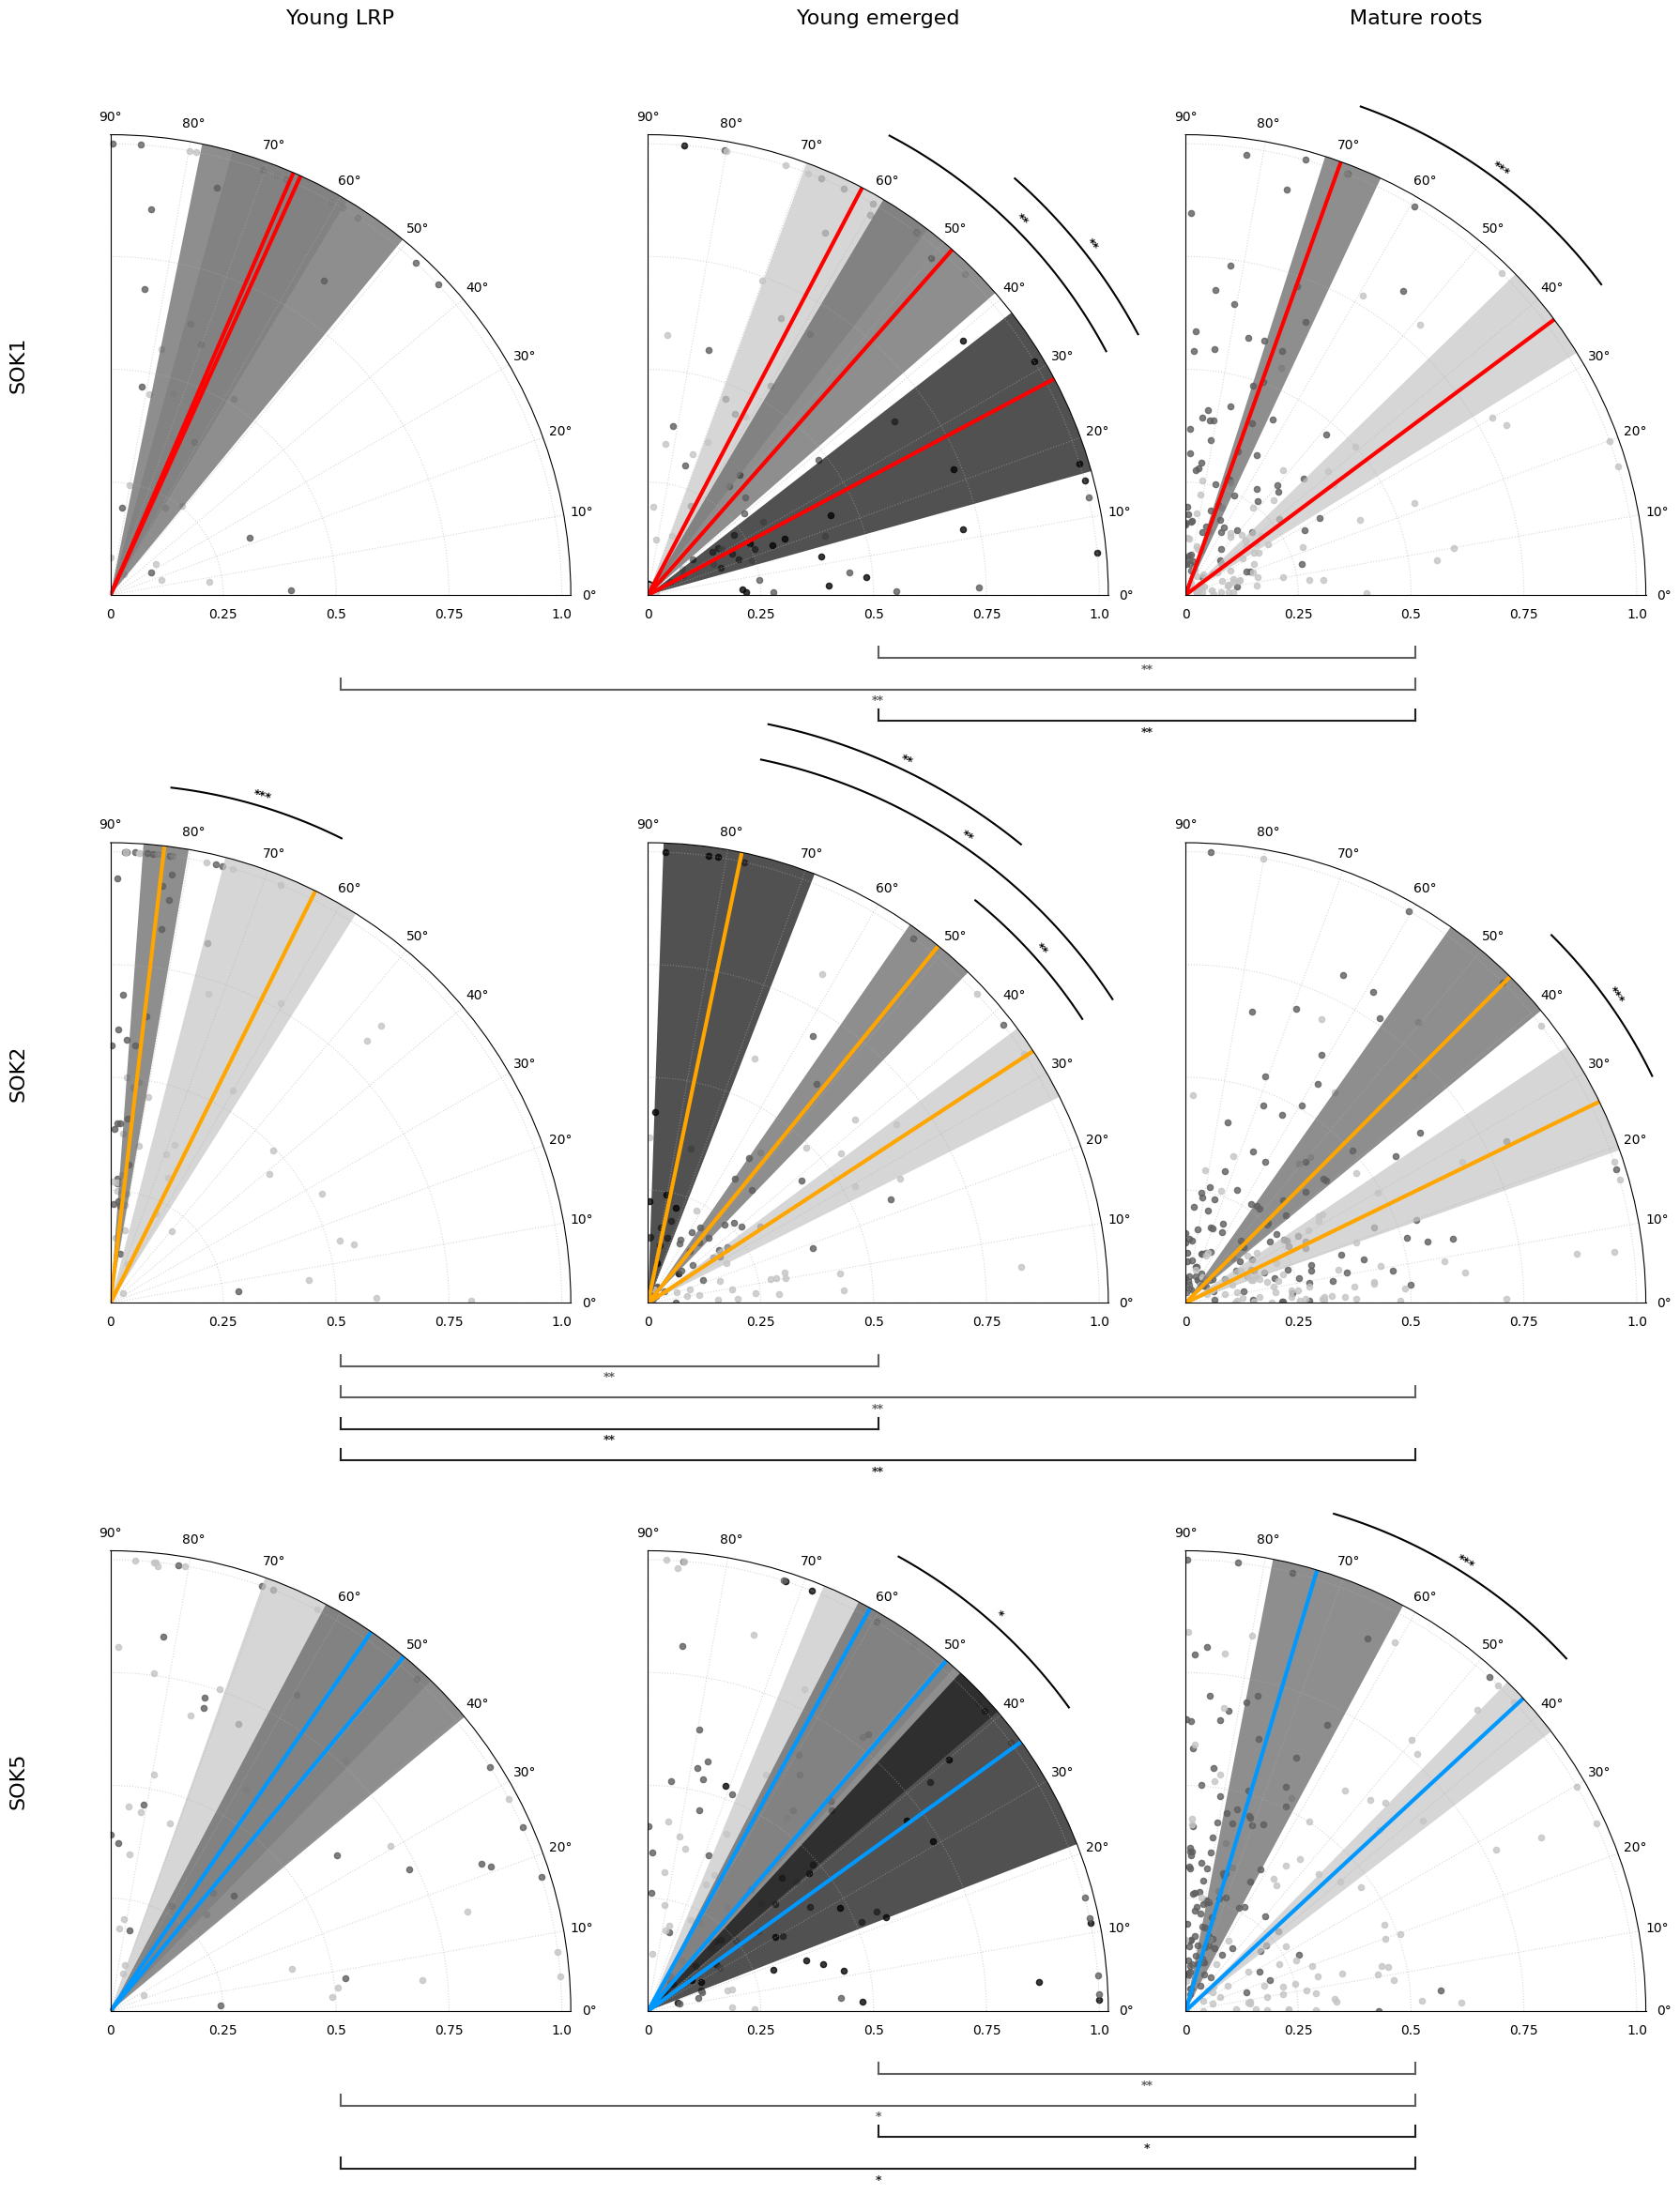

In [3]:
# Plot-only adjustment cell: re-position existing cross-stage significance brackets
# Reuses already computed/drawn figure from Cell 2 (no bootstrap/statistics recalculation).
import matplotlib.lines as mlines
from IPython.display import display

required_vars = ['fig', 'axs', 'sok_list', 'col_folders', 'tissues_to_compare', 'all_stage_pairs']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        f"Missing variables from Cell 2: {missing}. Run Cell 2 once, then run this cell for layout-only tweaks."
    )

# Layout tuning knobs (safe to tweak repeatedly)
base_gap = 0.028              # increased so bracket ticks clear the x-axis
desired_level_height = 0.014
top_margin = 0.035
bottom_margin = 0.030
inter_row_margin = 0.110      # increased row gap to make room for bottom brackets
row_buffer = 0.010            # extra separation from the next row above
tick_h = 0.005
text_offset = 0.003
star_drop_base = tick_h + text_offset + 0.001
min_level_height = 0.004
between_tissue_arc_base_offset = 0.13
between_tissue_arc_line_gap = 0.08
between_tissue_arc_text_offset = 0.01

# Display controls
show_ns = False  # Set True to keep non-significant cross-stage brackets
show_ns_between_tissues = False  # Set True to keep non-significant between-tissue arc brackets

n_rows = len(sok_list)
n_levels_per_row = len(tissues_to_compare) * len(all_stage_pairs)
expected_brackets = n_rows * n_levels_per_row
expected_lines = expected_brackets * 3

# Increase vertical space between SOK rows so bottom brackets do not overlap next row.
row_heights = [axs[r, 0].get_position().height for r in range(n_rows)]
new_row_h = min(row_heights)
max_row_h = (1.0 - top_margin - bottom_margin - (n_rows - 1) * inter_row_margin) / n_rows
new_row_h = min(new_row_h, max_row_h)

if new_row_h <= 0:
    raise RuntimeError("Not enough vertical space for requested margins; reduce inter_row_margin or bottom_margin.")

y_top = 1.0 - top_margin
for row_idx in range(n_rows):
    y1 = y_top
    y0 = y1 - new_row_h
    for col_idx in range(len(col_folders)):
        pos = axs[row_idx, col_idx].get_position()
        axs[row_idx, col_idx].set_position([pos.x0, y0, pos.width, new_row_h])
    y_top = y0 - inter_row_margin

fig.canvas.draw()

# Find bracket lines drawn in figure space by draw_figure_bracket (3 lines per bracket)
line_candidates = [
    artist for artist in fig.artists
    if isinstance(artist, mlines.Line2D)
    and artist.get_transform() == fig.transFigure
    and artist.get_clip_on() is False
    and len(np.asarray(artist.get_xdata())) == 2
    and len(np.asarray(artist.get_ydata())) == 2
]

# Bracket labels are the significance stars drawn in figure space
star_labels = {'ns', '*', '**', '***', '****'}
text_candidates = [
    txt for txt in fig.texts
    if txt.get_transform() == fig.transFigure and txt.get_text() in star_labels
]

if len(line_candidates) < expected_lines or len(text_candidates) < expected_brackets:
    raise RuntimeError(
        "Could not find all expected bracket artists/texts. "
        "Re-run Cell 2 once, then run this cell again."
    )

# If Cell 3 is run multiple times, remove older duplicate bracket artists/texts.
if len(line_candidates) > expected_lines:
    for artist in line_candidates[:-expected_lines]:
        artist.remove()
if len(text_candidates) > expected_brackets:
    for txt in text_candidates[:-expected_brackets]:
        txt.remove()

# Recollect after cleanup and keep the latest complete set.
line_candidates = [
    artist for artist in fig.artists
    if isinstance(artist, mlines.Line2D)
    and artist.get_transform() == fig.transFigure
    and artist.get_clip_on() is False
    and len(np.asarray(artist.get_xdata())) == 2
    and len(np.asarray(artist.get_ydata())) == 2
][-expected_lines:]

text_candidates = [
    txt for txt in fig.texts
    if txt.get_transform() == fig.transFigure and txt.get_text() in star_labels
][-expected_brackets:]

# Pass 1: compute visible levels and per-row capacity, now anchored below each row.
row_visible_levels = {}
row_y_bottom = {}
row_level_height = {}

for row_idx in range(n_rows):
    y_bottom = axs[row_idx, 0].get_position().y0
    if row_idx == n_rows - 1:
        lower_limit = bottom_margin
    else:
        lower_limit = max(
            axs[row_idx + 1, c].get_position().y1 for c in range(len(col_folders))
        ) + row_buffer

    visible_levels = []
    for level_idx in range(n_levels_per_row):
        bracket_idx = row_idx * n_levels_per_row + level_idx
        label = text_candidates[bracket_idx].get_text().strip()
        if (not show_ns) and label == 'ns':
            continue
        visible_levels.append(level_idx)

    n_visible = len(visible_levels)
    if n_visible <= 1:
        level_height = desired_level_height
    else:
        available_height = (y_bottom - base_gap) - lower_limit
        cap = max(min_level_height, available_height / (n_visible - 1))
        level_height = min(desired_level_height, cap)

    row_visible_levels[row_idx] = visible_levels
    row_y_bottom[row_idx] = y_bottom
    row_level_height[row_idx] = level_height

# Pass 2: apply visibility and positions with per-row spacing, descending downward.
for row_idx in range(n_rows):
    visible_levels = row_visible_levels[row_idx]
    visible_rank = {level_idx: rank for rank, level_idx in enumerate(visible_levels)}
    y_bottom = row_y_bottom[row_idx]
    level_height = row_level_height[row_idx]
    y_start = y_bottom - base_gap
    star_drop = min(star_drop_base, 0.15 * level_height)

    for level_idx in range(n_levels_per_row):
        bracket_idx = row_idx * n_levels_per_row + level_idx

        # Each bracket has 3 lines: horizontal, left tick, right tick
        i0 = bracket_idx * 3
        hline = line_candidates[i0]
        ltick = line_candidates[i0 + 1]
        rtick = line_candidates[i0 + 2]
        label = text_candidates[bracket_idx].get_text().strip()

        if (not show_ns) and label == 'ns':
            hline.set_visible(False)
            ltick.set_visible(False)
            rtick.set_visible(False)
            text_candidates[bracket_idx].set_visible(False)
            continue

        y = y_start - visible_rank[level_idx] * level_height

        hline.set_visible(True)
        ltick.set_visible(True)
        rtick.set_visible(True)
        text_candidates[bracket_idx].set_visible(True)

        xh = np.asarray(hline.get_xdata())
        xl = np.asarray(ltick.get_xdata())
        xr = np.asarray(rtick.get_xdata())

        hline.set_xdata(xh)
        hline.set_ydata([y, y])
        ltick.set_xdata(xl)
        ltick.set_ydata([y, y + tick_h])
        rtick.set_xdata(xr)
        rtick.set_ydata([y, y + tick_h])

        txt = text_candidates[bracket_idx]
        txt.set_position((np.mean(xh), y - star_drop))
        txt.set_ha('center')
        txt.set_va('top')
        txt.set_rotation(0)

# Hide NS between-tissue arc brackets and compact remaining brackets toward the plot.
for ax in np.ravel(axs):
    arc_lines = [
        ln for ln in ax.lines
        if len(np.asarray(ln.get_xdata())) > 2
        and len(np.asarray(ln.get_ydata())) > 2
        and np.ptp(np.asarray(ln.get_ydata())) < 1e-12
        and np.max(np.asarray(ln.get_ydata())) > ci_r_max
    ]
    star_texts = [txt for txt in ax.texts if txt.get_text().strip() in star_labels]

    pairs = []
    for ln, txt in zip(arc_lines, star_texts):
        r_old = float(np.mean(np.asarray(ln.get_ydata())))
        pairs.append((r_old, ln, txt))
    pairs.sort(key=lambda item: item[0])

    visible_pairs = []
    for _, ln, txt in pairs:
        label = txt.get_text().strip()
        if (not show_ns_between_tissues) and label == 'ns':
            ln.set_visible(False)
            txt.set_visible(False)
            continue
        ln.set_visible(True)
        txt.set_visible(True)
        visible_pairs.append((ln, txt))

    for rank, (ln, txt) in enumerate(visible_pairs):
        r_new = ci_r_max + between_tissue_arc_base_offset + rank * between_tissue_arc_line_gap
        theta_vals = np.asarray(ln.get_xdata())
        ln.set_ydata(np.full_like(theta_vals, r_new, dtype=float))

        theta_text, _ = txt.get_position()
        txt.set_position((theta_text, r_new + between_tissue_arc_text_offset))

fig.canvas.draw()

# Optional: save the adjusted layout without recomputing statistics
output_dir = sok_base / 'figures'
output_dir.mkdir(exist_ok=True)
filename = output_dir / '3x3_polar_plots_norm-per-tissue-sample_cross-stage-stats_plot-only-adjusted.svg'
fig.savefig(filename, format='svg', bbox_inches='tight')
print(f'Saved plot-only adjusted figure: {filename}')
print(f'Row bracket spacings used: {[round(row_level_height[r], 4) for r in range(n_rows)]}')

# Explicit display is more reliable than plt.show() when reusing an existing Figure object.
display(fig)


SOK5 pairwise comparisons used for unified abc letters:
       group_i        group_j    p_adj  significant               method    p_raw
     II - IV-G      II - IV-V 1.000000        False bootstrap_bonferroni 0.392804
     II - IV-G IV - Emerged-G 1.000000        False bootstrap_bonferroni 0.926537
     II - IV-G IV - Emerged-V 1.000000        False bootstrap_bonferroni 0.373813
     II - IV-G IV - Emerged-A 1.000000        False bootstrap_bonferroni 0.063968
     II - IV-G Mature roots-G 0.167916        False bootstrap_bonferroni 0.007996
     II - IV-G Mature roots-V 1.000000        False bootstrap_bonferroni 0.157921
     II - IV-V IV - Emerged-G 1.000000        False bootstrap_bonferroni 0.416792
     II - IV-V IV - Emerged-V 1.000000        False bootstrap_bonferroni 0.913543
     II - IV-V IV - Emerged-A 0.083958        False bootstrap_bonferroni 0.003998
     II - IV-V Mature roots-G 1.000000        False bootstrap_bonferroni 0.062969
     II - IV-V Mature roots-V 0.104948   

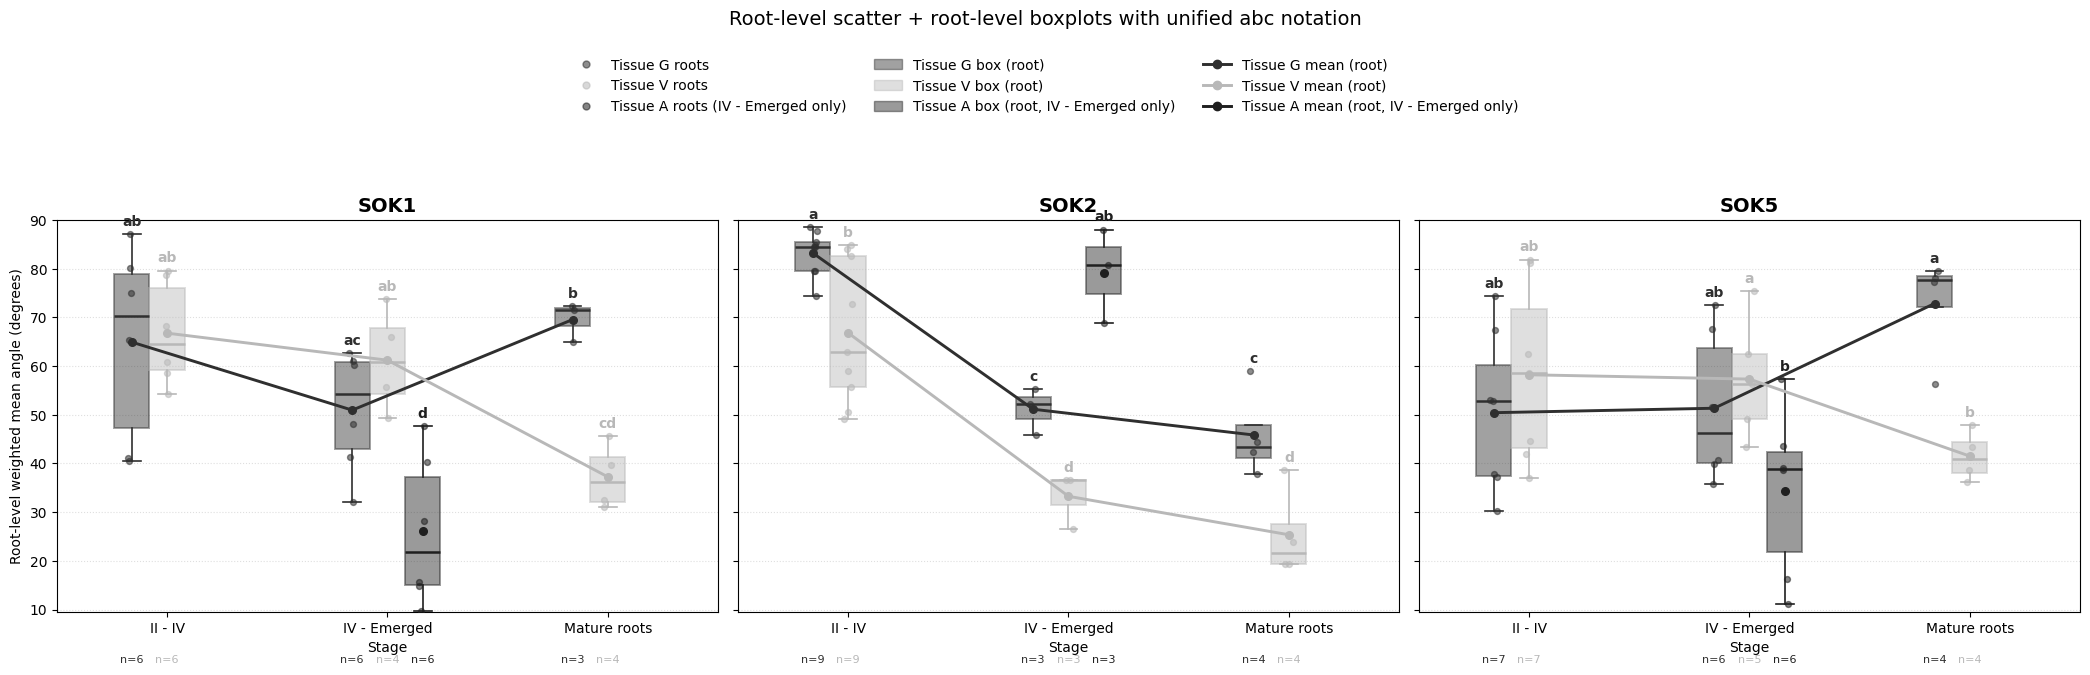

In [4]:
# Root-level scatter + root-level boxplots with unified abc notation (includes stage and tissue comparisons)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations

required_vars = ['all_stage_dfs', 'sok_list', 'col_folders']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        f"Missing variables from Cell 2: {missing}. Run Cell 2 once, then run this cell."
    )

# --- User knobs ---
tissues_to_use = ['G', 'V', 'A']
show_points = True
point_alpha = 0.55
box_alpha = 0.45
box_width = 0.16
stage_offset = {'G': -0.16, 'V': 0.0, 'A': 0.16}
point_jitter = 0.02
alpha_sig = 0.05
n_boot = 2000

stage_label_map = {
    'young LRP': 'II - IV',
    'young emerged': 'IV - Emerged',
    'mature roots': 'Mature roots'
}

tissue_colors = {'A': '#1f1f1f', 'G': '#2f2f2f', 'V': '#b8b8b8'}
stage_labels = [stage_label_map.get(stage, stage) for stage in col_folders]
x = np.arange(len(col_folders))

def root_level_means_from_df(df):
    """Collapse each root to one weighted mean angle to avoid cell-level pseudoreplication."""
    out = []
    for root in df['source_file'].unique():
        g = df[df['source_file'] == root]
        w = g['r'].values
        a = g['deviation_degrees'].values
        m = np.average(a, weights=w) if np.sum(w) > 0 else np.mean(a)
        out.append(float(m))
    return np.array(out, dtype=float)

def bootstrap_two_sided_p(a, b, n_boot=2000):
    """Two-sided bootstrap test on root-level mean differences (same method as 3x3 cell)."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if len(a) < 2 or len(b) < 2:
        return np.nan

    diffs = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        diffs[i] = (
            np.mean(np.random.choice(a, size=len(a), replace=True))
            - np.mean(np.random.choice(b, size=len(b), replace=True))
        )

    tail_ge = (np.sum(diffs >= 0) + 1) / (len(diffs) + 1)
    tail_le = (np.sum(diffs <= 0) + 1) / (len(diffs) + 1)
    return float(min(2 * min(tail_ge, tail_le), 1.0))

def cld_letters_from_significance(sig_matrix):
    """Compact letter display where True means groups are significantly different."""
    n = sig_matrix.shape[0]
    columns = [set(range(n))]

    sig_pairs = [(i, j) for i in range(n) for j in range(i + 1, n) if sig_matrix[i, j]]

    for i, j in sig_pairs:
        new_cols = []
        for col in columns:
            if i in col and j in col:
                c1 = set(col); c1.remove(j)
                c2 = set(col); c2.remove(i)
                if c1:
                    new_cols.append(c1)
                if c2:
                    new_cols.append(c2)
            else:
                new_cols.append(set(col))

        unique_cols = []
        seen = set()
        for c in new_cols:
            key = tuple(sorted(c))
            if key not in seen:
                seen.add(key)
                unique_cols.append(c)

        maximal = []
        for c in unique_cols:
            if not any((c < d) for d in unique_cols):
                maximal.append(c)
        columns = maximal

    alphabet = list('abcdefghijklmnopqrstuvwxyz')
    if len(columns) > len(alphabet):
        alphabet += [f'a{i}' for i in range(1, len(columns) - len(alphabet) + 1)]

    letters = ['' for _ in range(n)]
    for col_idx, col in enumerate(columns):
        letter = alphabet[col_idx]
        for i in sorted(col):
            letters[i] += letter
    return letters

def build_significance_matrix(group_samples, alpha_sig=0.05, n_boot=2000):
    """Bootstrap-based pairwise tests with Bonferroni correction (matching 3x3 method)."""
    n = len(group_samples)
    sig = np.zeros((n, n), dtype=bool)
    debug_rows = []

    pairwise = []
    valid_pvals = []
    for i, j in combinations(range(n), 2):
        p_raw = bootstrap_two_sided_p(group_samples[i], group_samples[j], n_boot=n_boot)
        pairwise.append((i, j, p_raw))
        if np.isfinite(p_raw):
            valid_pvals.append(p_raw)

    m_all = len(valid_pvals) if len(valid_pvals) else 1

    for i, j, p_raw in pairwise:
        if np.isfinite(p_raw):
            p_adj = min(p_raw * m_all, 1.0)
            is_sig = p_adj < alpha_sig
        else:
            p_adj = np.nan
            is_sig = False

        sig[i, j] = sig[j, i] = is_sig
        debug_rows.append({
            'group_i_idx': i,
            'group_j_idx': j,
            'p_raw': p_raw,
            'p_adj': p_adj,
            'significant': is_sig,
            'method': 'bootstrap_bonferroni'
        })

    return sig, debug_rows, 'bootstrap_bonferroni'

# Build root-level records from all_stage_dfs.
records = []
for row_idx, sok in enumerate(sok_list):
    for col_idx, stage in enumerate(col_folders):
        for tissue in tissues_to_use:
            # Tissue A exists only for the IV-Emerged stage in this figure.
            if tissue == 'A' and stage != 'young emerged':
                continue
            key = (row_idx, col_idx, tissue)
            if key not in all_stage_dfs:
                continue
            df = all_stage_dfs[key]
            if df.empty:
                continue
            root_vals = root_level_means_from_df(df)
            for v in root_vals:
                records.append({
                    'SOK': sok,
                    'stage': stage,
                    'stage_idx': col_idx,
                    'tissue': tissue,
                    'value': float(v)
                })

plot_df = pd.DataFrame(records)
if plot_df.empty:
    raise RuntimeError('No root-level data available from all_stage_dfs.')

n_cols = len(sok_list)
fig, axs = plt.subplots(1, n_cols, figsize=(7 * n_cols, 6), sharey=True)
if n_cols == 1:
    axs = [axs]

all_values = []
annotation_tops = []
sok5_debug_rows = []

for ax, sok in zip(axs, sok_list):
    sdf = plot_df[plot_df['SOK'] == sok].copy()
    if sdf.empty:
        ax.set_visible(False)
        continue

    # Keep per-tissue root samples for plotting.
    tissue_root_samples = {}
    tissue_positions = {}

    for tissue in tissues_to_use:
        root_samples = []
        for col_idx, stage in enumerate(col_folders):
            if tissue == 'A' and stage != 'young emerged':
                vals = np.array([], dtype=float)
            else:
                vals = sdf.loc[
                    (sdf['stage_idx'] == col_idx) & (sdf['tissue'] == tissue),
                    'value'
                ].values
            root_samples.append(vals)

        for vals in root_samples:
            if len(vals):
                all_values.extend(vals.tolist())

        x_pos = x + stage_offset[tissue]
        tissue_root_samples[tissue] = root_samples
        tissue_positions[tissue] = x_pos

        # Root-level boxplots (draw only non-empty groups).
        non_empty_idx = [i for i, vals in enumerate(root_samples) if len(vals) > 0]
        if non_empty_idx:
            samples_for_box = [root_samples[i] for i in non_empty_idx]
            pos_for_box = [x_pos[i] for i in non_empty_idx]
            bp = ax.boxplot(
                samples_for_box,
                positions=pos_for_box,
                widths=box_width,
                patch_artist=True,
                showfliers=False,
                medianprops={'color': tissue_colors[tissue], 'linewidth': 1.8},
                whiskerprops={'color': tissue_colors[tissue], 'linewidth': 1.2},
                capprops={'color': tissue_colors[tissue], 'linewidth': 1.2},
                boxprops={'edgecolor': tissue_colors[tissue], 'linewidth': 1.4}
            )
            for patch in bp['boxes']:
                patch.set_facecolor(tissue_colors[tissue])
                patch.set_alpha(box_alpha)

        # Root-level scatter
        if show_points:
            for col_idx, vals in enumerate(root_samples):
                if len(vals) == 0:
                    continue
                jitter = np.random.uniform(-point_jitter, point_jitter, size=len(vals))
                ax.scatter(
                    np.full(len(vals), x_pos[col_idx]) + jitter,
                    vals,
                    s=18,
                    color=tissue_colors[tissue],
                    alpha=point_alpha,
                    zorder=3
                )

        # Show root sample size used in each boxplot (n roots).
        for col_idx, vals in enumerate(root_samples):
            if len(vals) == 0:
                continue
            ax.text(
                x_pos[col_idx],
                -0.11,
                f"n={len(vals)}",
                ha='center',
                va='top',
                fontsize=8,
                color=tissue_colors[tissue],
                transform=ax.get_xaxis_transform(),
                clip_on=False
            )

        # Root-level mean trend line
        means = np.array([np.mean(vals) if len(vals) else np.nan for vals in root_samples], dtype=float)
        valid = np.isfinite(means)
        if np.any(valid):
            ax.plot(
                x_pos[valid],
                means[valid],
                marker='o',
                linewidth=2.1,
                markersize=5.5,
                color=tissue_colors[tissue],
                zorder=5
            )

    # Unified CLD across all stage x tissue groups: includes between-tissue comparisons.
    group_labels = []
    group_positions = []
    group_samples = []
    for col_idx, stage in enumerate(col_folders):
        for tissue in tissues_to_use:
            if tissue == 'A' and stage != 'young emerged':
                continue
            group_labels.append(f"{stage_labels[col_idx]}-{tissue}")
            group_positions.append(tissue_positions[tissue][col_idx])
            group_samples.append(tissue_root_samples[tissue][col_idx])

    sig, comp_debug_rows, method_used = build_significance_matrix(
        group_samples,
        alpha_sig=alpha_sig,
        n_boot=n_boot
    )

    if sok == 'SOK5':
        for row in comp_debug_rows:
            entry = {
                'group_i': group_labels[row['group_i_idx']],
                'group_j': group_labels[row['group_j_idx']],
                'p_adj': row['p_adj'],
                'significant': row['significant'],
                'method': row['method']
            }
            if 'p_raw' in row:
                entry['p_raw'] = row['p_raw']
            sok5_debug_rows.append(entry)

    letters = cld_letters_from_significance(sig)

    # Place unified letters above each plotted group.
    y_text_pad = 1.1
    for idx, vals in enumerate(group_samples):
        if len(vals) == 0:
            continue
        y_text = float(np.max(vals) + y_text_pad)
        tissue = group_labels[idx].split('-')[-1]
        ax.text(
            group_positions[idx],
            y_text,
            letters[idx],
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
            color=tissue_colors[tissue],
            zorder=6
        )
        annotation_tops.append(y_text)

    ax.set_xticks(x)
    ax.set_xticklabels(stage_labels)
    ax.set_xlim(-0.5, len(col_folders) - 1 + 0.5)
    ax.set_title(sok, fontsize=14, fontweight='bold')
    ax.set_xlabel('Stage')
    ax.grid(axis='y', linestyle=':', alpha=0.4)

# Auto zoom around root-level distribution with headroom for annotations, bounded by biological range.
if len(all_values):
    q1, q99 = np.percentile(all_values, [1, 99])
    y0 = max(0, q1 - 2.0)
    y1_base = q99 + 4.0
else:
    y0, y1_base = 0, 90

ann_top = max(annotation_tops) if annotation_tops else y1_base
y1 = min(90, max(y1_base, ann_top + 1.0))

for ax in axs:
    if ax.get_visible():
        ax.set_ylim(y0, y1)

axs[0].set_ylabel('Root-level weighted mean angle (degrees)')

# Single shared legend outside subplots.
legend_handles = [
    plt.Line2D([0], [0], marker='o', color=tissue_colors['G'], linestyle='None', markersize=5, alpha=point_alpha),
    plt.Line2D([0], [0], marker='o', color=tissue_colors['V'], linestyle='None', markersize=5, alpha=point_alpha),
    plt.Line2D([0], [0], marker='o', color=tissue_colors['A'], linestyle='None', markersize=5, alpha=point_alpha),
    plt.Rectangle((0, 0), 1, 1, facecolor=tissue_colors['G'], edgecolor=tissue_colors['G'], alpha=box_alpha),
    plt.Rectangle((0, 0), 1, 1, facecolor=tissue_colors['V'], edgecolor=tissue_colors['V'], alpha=box_alpha),
    plt.Rectangle((0, 0), 1, 1, facecolor=tissue_colors['A'], edgecolor=tissue_colors['A'], alpha=box_alpha),
    plt.Line2D([0], [0], color=tissue_colors['G'], marker='o', linewidth=2.1),
    plt.Line2D([0], [0], color=tissue_colors['V'], marker='o', linewidth=2.1),
    plt.Line2D([0], [0], color=tissue_colors['A'], marker='o', linewidth=2.1),
]
legend_labels = [
    'Tissue G roots',
    'Tissue V roots',
    'Tissue A roots (IV - Emerged only)',
    'Tissue G box (root)',
    'Tissue V box (root)',
    'Tissue A box (root, IV - Emerged only)',
    'Tissue G mean (root)',
    'Tissue V mean (root)',
    'Tissue A mean (root, IV - Emerged only)'
 ]
fig.legend(
    legend_handles,
    legend_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.07),
    ncol=3,
    frameon=False
 )

fig.suptitle('Root-level scatter + root-level boxplots with unified abc notation', fontsize=14, y=1.13)
fig.tight_layout(rect=[0, 0, 1, 0.9])

# Print SOK5 debug p-values so significance can be verified directly.
if sok5_debug_rows:
    dbg = pd.DataFrame(sok5_debug_rows)
    print('\nSOK5 pairwise comparisons used for unified abc letters:')
    print(dbg.to_string(index=False))

print(f"\nPairwise method for root-level CLD: {method_used} (n_boot={n_boot}, correction=Bonferroni)")

output_dir = sok_base / 'figures' if 'sok_base' in globals() else Path('.')
output_dir.mkdir(exist_ok=True)
out_file = output_dir / 'boxplot_root-level_unified-abc_including-between-tissue.svg'
fig.savefig(out_file, format='svg', bbox_inches='tight')
print(f'Saved: {out_file}')
print(f'Y-axis zoom: {y0:.2f} to {y1:.2f} degrees')

plt.show()

In [5]:
# Roots and cells per developmental stage per SOK
import pandas as pd

required_vars = ['all_stage_dfs', 'sok_list', 'col_folders']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        f"Missing variables from earlier cells: {missing}. Run the data-loading/stat cells first."
    )

count_rows = []
for row_idx, sok in enumerate(sok_list):
    for col_idx, stage in enumerate(col_folders):
        stage_dfs = []
        for tissue in ['G', 'V']:
            key = (row_idx, col_idx, tissue)
            if key in all_stage_dfs:
                df = all_stage_dfs[key]
                if not df.empty:
                    stage_dfs.append(df)

        if stage_dfs:
            stage_df = pd.concat(stage_dfs, ignore_index=True)
            n_roots = stage_df['source_file'].nunique()
            n_cells = len(stage_df)
        else:
            n_roots = 0
            n_cells = 0

        count_rows.append({
            'SOK': sok,
            'Stage': stage,
            'Roots': int(n_roots),
            'Cells': int(n_cells)
        })

counts_df = pd.DataFrame(count_rows)

# Keep ordering consistent with plotting order.
counts_df['SOK'] = pd.Categorical(counts_df['SOK'], categories=sok_list, ordered=True)
counts_df['Stage'] = pd.Categorical(counts_df['Stage'], categories=col_folders, ordered=True)
counts_df = counts_df.sort_values(['SOK', 'Stage']).reset_index(drop=True)

print('Roots and cells per developmental stage per SOK:')
print(counts_df.to_string(index=False))


Roots and cells per developmental stage per SOK:
 SOK         Stage  Roots  Cells
SOK1     young LRP      6     36
SOK1 young emerged      7     65
SOK1  mature roots      4    170
SOK2     young LRP      9     76
SOK2 young emerged      3     79
SOK2  mature roots      4    215
SOK5     young LRP      7     60
SOK5 young emerged      6     82
SOK5  mature roots      4    209


In [6]:
# Sensitivity check: compare root-level vs cell-level Tukey HSD (same stage x tissue groups)
import numpy as np
import pandas as pd

required_vars = ['all_stage_dfs', 'sok_list', 'col_folders']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        f"Missing variables from earlier cells: {missing}. Run the data-loading/stat cells first."
    )

try:
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
except Exception as exc:
    raise RuntimeError("statsmodels is required for Tukey HSD. Install/import statsmodels first.") from exc

stage_label_map = {
    'young LRP': 'II - IV',
    'young emerged': 'IV - Emerged',
    'mature roots': 'Mature roots'
}
tissues_to_use = ['G', 'V', 'A']

def root_level_means_from_df(df):
    out = []
    for root in df['source_file'].unique():
        g = df[df['source_file'] == root]
        w = g['r'].values
        a = g['deviation_degrees'].values
        m = np.average(a, weights=w) if np.sum(w) > 0 else np.mean(a)
        out.append(float(m))
    return np.array(out, dtype=float)

def build_record_tables():
    root_records = []
    cell_records = []

    for row_idx, sok in enumerate(sok_list):
        for col_idx, stage in enumerate(col_folders):
            stage_label = stage_label_map.get(stage, stage)
            for tissue in tissues_to_use:
                if tissue == 'A' and stage != 'young emerged':
                    continue

                key = (row_idx, col_idx, tissue)
                if key not in all_stage_dfs:
                    continue
                df = all_stage_dfs[key]
                if df.empty:
                    continue

                group_label = f"{stage_label}-{tissue}"

                # Root-level values (one weighted mean per root)
                root_vals = root_level_means_from_df(df)
                for v in root_vals:
                    root_records.append({
                        'SOK': sok,
                        'group': group_label,
                        'value': float(v)
                    })

                # Cell-level values (raw cell angles)
                cell_vals = pd.to_numeric(df['deviation_degrees'], errors='coerce').dropna().values
                for v in cell_vals:
                    cell_records.append({
                        'SOK': sok,
                        'group': group_label,
                        'value': float(v)
                    })

    return pd.DataFrame(root_records), pd.DataFrame(cell_records)

def tukey_pairs_for_sok(df_one_sok):
    if df_one_sok.empty or df_one_sok['group'].nunique() < 2:
        return pd.DataFrame(columns=['group_i', 'group_j', 'p_adj', 'significant'])

    tuk = pairwise_tukeyhsd(
        endog=df_one_sok['value'].values.astype(float),
        groups=df_one_sok['group'].values,
        alpha=0.05
    )

    rows = []
    for row in tuk.summary().data[1:]:
        rows.append({
            'group_i': str(row[0]),
            'group_j': str(row[1]),
            'p_adj': float(row[3]),
            'significant': bool(row[6])
        })

    return pd.DataFrame(rows)

root_df, cell_df = build_record_tables()
if root_df.empty or cell_df.empty:
    raise RuntimeError('No records available for Tukey comparison.')

all_comparisons = []
summary_rows = []
for sok in sok_list:
    root_pairs = tukey_pairs_for_sok(root_df[root_df['SOK'] == sok]).rename(
        columns={'p_adj': 'p_adj_root', 'significant': 'sig_root'}
    )
    cell_pairs = tukey_pairs_for_sok(cell_df[cell_df['SOK'] == sok]).rename(
        columns={'p_adj': 'p_adj_cell', 'significant': 'sig_cell'}
    )

    merged = root_pairs.merge(cell_pairs, on=['group_i', 'group_j'], how='outer')
    merged.insert(0, 'SOK', sok)

    merged['sig_root'] = merged['sig_root'].fillna(False).astype(bool)
    merged['sig_cell'] = merged['sig_cell'].fillna(False).astype(bool)
    merged['p_adj_root'] = pd.to_numeric(merged['p_adj_root'], errors='coerce')
    merged['p_adj_cell'] = pd.to_numeric(merged['p_adj_cell'], errors='coerce')
    merged['changed_call'] = merged['sig_root'] != merged['sig_cell']

    all_comparisons.append(merged)

    summary_rows.append({
        'SOK': sok,
        'root_significant_pairs': int(merged['sig_root'].sum()),
        'cell_significant_pairs': int(merged['sig_cell'].sum()),
        'changed_calls': int(merged['changed_call'].sum())
    })

comparison_df = pd.concat(all_comparisons, ignore_index=True)
summary_df = pd.DataFrame(summary_rows)

print('Tukey comparison summary (root-level vs cell-level):')
print(summary_df.to_string(index=False))

print('\nPairwise details (only changed calls):')
changed_df = comparison_df[comparison_df['changed_call']].copy()
if changed_df.empty:
    print('No changed significance calls between root-level and cell-level Tukey.')
else:
    cols = ['SOK', 'group_i', 'group_j', 'p_adj_root', 'sig_root', 'p_adj_cell', 'sig_cell']
    print(changed_df[cols].sort_values(['SOK', 'group_i', 'group_j']).to_string(index=False))

# Keep full table available for downstream inspection.
comparison_tukey_root_vs_cell = comparison_df.copy()
summary_tukey_root_vs_cell = summary_df.copy()

Tukey comparison summary (root-level vs cell-level):
 SOK  root_significant_pairs  cell_significant_pairs  changed_calls
SOK1                       7                       9              4
SOK2                      13                      15              4
SOK5                       1                       9              8

Pairwise details (only changed calls):
 SOK        group_i        group_j  p_adj_root  sig_root  p_adj_cell  sig_cell
SOK1 IV - Emerged-A IV - Emerged-G      0.0453      True      0.5776     False
SOK1 IV - Emerged-G Mature roots-G      0.4592     False      0.0001      True
SOK1 IV - Emerged-V Mature roots-V      0.1876     False      0.0000      True
SOK1 Mature roots-G Mature roots-V      0.0519     False      0.0000      True
SOK2 IV - Emerged-A IV - Emerged-G      0.0214      True      0.3485     False
SOK2 IV - Emerged-G IV - Emerged-V      0.3007     False      0.0005      True
SOK2 IV - Emerged-V Mature roots-G      0.6237     False      0.0155      True
SOK


Cells by tissue and independent roots by stage for the boxplot:
      cells | Stage II-IV - G  cells | Stage II-IV - V  cells | Stage IV-Emerged - G  cells | Stage IV-Emerged - V  cells | Stage IV-Emerged - A  cells | Mature roots - G  cells | Mature roots - V  independent_roots | Stage II-IV  independent_roots | Stage IV-Emerged  independent_roots | Mature roots
SOK                                                                                                                                                                                                                                                                                                          
SOK1                     16.0                     14.0                          32.0                          13.0                          19.0                      51.0                      30.0                              6.0                                   7.0                               4.0
SOK2                     32.0

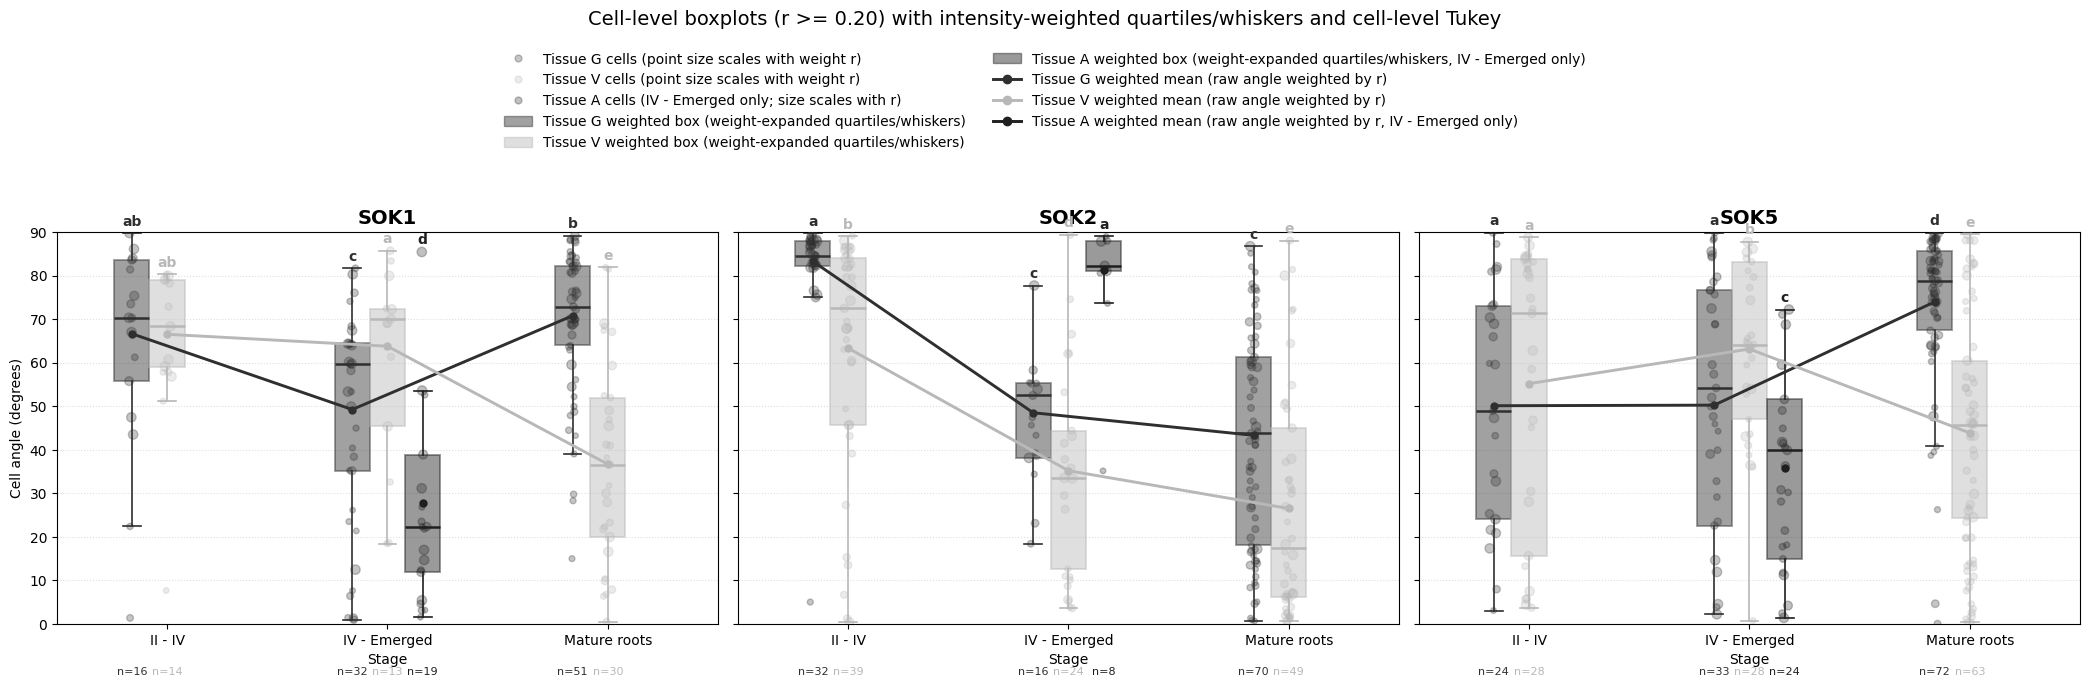

In [7]:
# Cell-level scatter + cell-level boxplots with unified abc notation
# Intensity weighting is applied as contribution weight (not by multiplying angle units).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

required_vars = ['all_stage_dfs', 'sok_list', 'col_folders']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        f"Missing variables from Cell 2: {missing}. Run Cell 2 once, then run this cell."
    )

try:
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
except Exception as exc:
    raise RuntimeError("statsmodels is required for Tukey HSD. Install/import statsmodels first.") from exc

# --- User knobs ---
tissues_to_use = ['G', 'V', 'A']
show_points = True
point_alpha = 0.28
box_alpha = 0.45
box_width = 0.16
stage_offset = {'G': -0.16, 'V': 0.0, 'A': 0.16}
point_jitter = 0.02
alpha_sig = 0.05

# Weighting settings:
# - Boxplots use high-resolution weight-expanded distributions for quartiles/whiskers.
# - Tukey uses weighted expansion (replication by weight bins).
# - Scatter marker size scales continuously with weight.
weight_scale = 20
min_rep = 1
max_rep = 20
min_point_size = 8
max_point_size = 46
box_expand_target = 4000
min_intensity_keep = 0.2

stage_label_map = {
    'young LRP': 'II - IV',
    'young emerged': 'IV - Emerged',
    'mature roots': 'Mature roots'
}
stage_column_label_map = {
    'young LRP': 'Stage II-IV',
    'young emerged': 'Stage IV-Emerged',
    'mature roots': 'Mature roots'
}

tissue_colors = {'A': '#1f1f1f', 'G': '#2f2f2f', 'V': '#b8b8b8'}
stage_labels = [stage_label_map.get(stage, stage) for stage in col_folders]
x = np.arange(len(col_folders))

def cld_letters_from_significance(sig_matrix):
    """Compact letter display where True means groups are significantly different."""
    n = sig_matrix.shape[0]
    columns = [set(range(n))]

    sig_pairs = [(i, j) for i in range(n) for j in range(i + 1, n) if sig_matrix[i, j]]

    for i, j in sig_pairs:
        new_cols = []
        for col in columns:
            if i in col and j in col:
                c1 = set(col); c1.remove(j)
                c2 = set(col); c2.remove(i)
                if c1:
                    new_cols.append(c1)
                if c2:
                    new_cols.append(c2)
            else:
                new_cols.append(set(col))

        unique_cols = []
        seen = set()
        for c in new_cols:
            key = tuple(sorted(c))
            if key not in seen:
                seen.add(key)
                unique_cols.append(c)

        maximal = []
        for c in unique_cols:
            if not any((c < d) for d in unique_cols):
                maximal.append(c)
        columns = maximal

    alphabet = list('abcdefghijklmnopqrstuvwxyz')
    if len(columns) > len(alphabet):
        alphabet += [f'a{i}' for i in range(1, len(columns) - len(alphabet) + 1)]

    letters = ['' for _ in range(n)]
    for col_idx, col in enumerate(columns):
        letter = alphabet[col_idx]
        for i in sorted(col):
            letters[i] += letter
    return letters

def weighted_expand(values, weights, scale=20, min_rep=1, max_rep=20):
    """Approximate weighted sample by replicating points according to normalized intensity weight."""
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    if len(values) == 0:
        return np.array([], dtype=float)

    reps = np.rint(np.clip(weights, 0, 1) * scale).astype(int)
    reps = np.clip(reps, min_rep, max_rep)
    return np.repeat(values, reps)

def weighted_quantile(values, weights, quantiles):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    quantiles = np.asarray(quantiles, dtype=float)

    if len(values) == 0:
        return np.full(len(quantiles), np.nan)

    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values = values[mask]
    weights = weights[mask]
    if len(values) == 0:
        return np.full(len(quantiles), np.nan)

    order = np.argsort(values)
    values = values[order]
    weights = weights[order]

    cdf = np.cumsum(weights)
    total = cdf[-1]
    if total <= 0:
        return np.full(len(quantiles), np.nan)

    cdf_mid = (cdf - 0.5 * weights) / total
    cdf_mid = np.clip(cdf_mid, 0, 1)
    return np.interp(quantiles, cdf_mid, values)

def expand_by_weights(values, weights, target_n=4000):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values = values[mask]
    weights = weights[mask]
    if len(values) == 0:
        return np.array([], dtype=float)

    total = np.sum(weights)
    if total <= 0:
        return np.array([], dtype=float)

    probs = weights / total
    scaled = probs * float(target_n)
    reps = np.floor(scaled).astype(int)
    remainder = int(target_n - np.sum(reps))

    if remainder > 0:
        frac = scaled - reps
        top_idx = np.argsort(frac)[-remainder:]
        reps[top_idx] += 1

    if np.sum(reps) == 0:
        reps[np.argmax(weights)] = 1

    return np.repeat(values, reps)

def weighted_box_stats(values, weights, whis=1.5, expand_target=4000):
    expanded = expand_by_weights(values, weights, target_n=expand_target)
    if len(expanded) == 0:
        return None

    q1, med, q3 = np.percentile(expanded, [25, 50, 75])
    iqr = q3 - q1
    lo_bound = q1 - whis * iqr
    hi_bound = q3 + whis * iqr

    inliers = expanded[(expanded >= lo_bound) & (expanded <= hi_bound)]
    if len(inliers):
        whislo = float(np.min(inliers))
        whishi = float(np.max(inliers))
    else:
        whislo = float(np.min(expanded))
        whishi = float(np.max(expanded))

    return {
        'med': float(med),
        'q1': float(q1),
        'q3': float(q3),
        'whislo': whislo,
        'whishi': whishi,
        'fliers': []
    }

# Build raw cell-level records (angle + intensity weight) from all_stage_dfs.
records = []
count_rows = []
n_total_points = 0
n_kept_points = 0
for row_idx, sok in enumerate(sok_list):
    for col_idx, stage in enumerate(col_folders):
        stage_column_label = stage_column_label_map.get(stage, stage)
        stage_root_ids = set()
        for tissue in tissues_to_use:
            # Tissue A exists only for the IV-Emerged stage in this figure.
            if tissue == 'A' and stage != 'young emerged':
                continue
            key = (row_idx, col_idx, tissue)
            if key not in all_stage_dfs:
                count_rows.append({
                    'SOK': sok,
                    'stage_label': stage_column_label,
                    'tissue': tissue,
                    'cells': 0
                })
                continue
            df = all_stage_dfs[key]
            if df.empty:
                count_rows.append({
                    'SOK': sok,
                    'stage_label': stage_column_label,
                    'tissue': tissue,
                    'cells': 0
                })
                continue
            if 'source_file' not in df.columns:
                raise RuntimeError(
                    f"Missing source_file column for {sok}, {stage}, {tissue}. Available columns: {list(df.columns)}"
                )

            tmp = df[['deviation_degrees', 'r', 'source_file']].copy()
            tmp['deviation_degrees'] = pd.to_numeric(tmp['deviation_degrees'], errors='coerce')
            tmp['r'] = pd.to_numeric(tmp['r'], errors='coerce')
            tmp['source_file'] = tmp['source_file'].astype(str).str.strip()
            tmp = tmp.dropna(subset=['deviation_degrees', 'r'])
            n_total_points += len(tmp)
            tmp = tmp[(tmp['r'] >= min_intensity_keep) & (tmp['source_file'] != '')].copy()
            if tmp.empty:
                count_rows.append({
                    'SOK': sok,
                    'stage_label': stage_column_label,
                    'tissue': tissue,
                    'cells': 0
                })
                continue
            n_kept_points += len(tmp)
            stage_root_ids.update(tmp['source_file'].tolist())
            count_rows.append({
                'SOK': sok,
                'stage_label': stage_column_label,
                'tissue': tissue,
                'cells': int(len(tmp))
            })

            for _, row in tmp.iterrows():
                records.append({
                    'SOK': sok,
                    'stage': stage,
                    'stage_idx': col_idx,
                    'tissue': tissue,
                    'value': float(row['deviation_degrees']),
                    'weight': float(row['r'])
                })

        count_rows.append({
            'SOK': sok,
            'stage_label': stage_column_label,
            'tissue': 'ALL',
            'independent_roots': int(len(stage_root_ids))
        })

plot_df = pd.DataFrame(records)
if plot_df.empty:
    raise RuntimeError('No cell-level data available from all_stage_dfs.')
counts_df = pd.DataFrame(count_rows)
stage_categories = [stage_column_label_map.get(stage, stage) for stage in col_folders]
counts_df['SOK'] = pd.Categorical(counts_df['SOK'], categories=sok_list, ordered=True)
counts_df['stage_label'] = pd.Categorical(counts_df['stage_label'], categories=stage_categories, ordered=True)
counts_df = counts_df.sort_values(['SOK', 'stage_label']).reset_index(drop=True)
cells_df = counts_df[counts_df['tissue'].isin(tissues_to_use)].copy()
cells_df['tissue'] = pd.Categorical(cells_df['tissue'], categories=tissues_to_use, ordered=True)
cells_df = cells_df.sort_values(['SOK', 'stage_label', 'tissue']).reset_index(drop=True)
cells_part = cells_df.pivot(index='SOK', columns=['stage_label', 'tissue'], values='cells')
cells_part = cells_part.reindex(index=sok_list)
valid_cell_columns = []
for stage in col_folders:
    stage_label = stage_column_label_map.get(stage, stage)
    for tissue in tissues_to_use:
        if tissue == 'A' and stage != 'young emerged':
            continue
        valid_cell_columns.append((stage_label, tissue))
cells_part = cells_part.reindex(columns=pd.MultiIndex.from_tuples(valid_cell_columns))
cells_part.columns = [f"cells | {stage} - {tissue}" for stage, tissue in cells_part.columns]
roots_df = counts_df[counts_df['tissue'] == 'ALL'].copy()
roots_part = roots_df.pivot(index='SOK', columns='stage_label', values='independent_roots')
roots_part = roots_part.reindex(index=sok_list, columns=stage_categories)
roots_part.columns = [f"independent_roots | {stage}" for stage in roots_part.columns]
summary_wide_df = pd.concat([cells_part, roots_part], axis=1)
summary_wide_df.index.name = 'SOK'
print('\nCells by tissue and independent roots by stage for the boxplot:')
print(summary_wide_df.to_string())
print(f'Applied intensity filter: r >= {min_intensity_keep:.2f} | kept {n_kept_points}/{n_total_points} points ({(100.0 * n_kept_points / n_total_points if n_total_points else 0):.1f}%)')

n_cols = len(sok_list)
fig, axs = plt.subplots(1, n_cols, figsize=(7 * n_cols, 6), sharey=True)
if n_cols == 1:
    axs = [axs]

all_values = []
all_weights = []
annotation_tops = []
sok5_debug_rows = []

for ax, sok in zip(axs, sok_list):
    sdf = plot_df[plot_df['SOK'] == sok].copy()
    if sdf.empty:
        ax.set_visible(False)
        continue

    tissue_values = {}
    tissue_weights = {}
    tissue_expanded = {}
    tissue_positions = {}

    for tissue in tissues_to_use:
        group_values = []
        group_weights = []
        group_expanded = []

        for col_idx, stage in enumerate(col_folders):
            if tissue == 'A' and stage != 'young emerged':
                vals = np.array([], dtype=float)
                wts = np.array([], dtype=float)
            else:
                sub = sdf.loc[
                    (sdf['stage_idx'] == col_idx) & (sdf['tissue'] == tissue),
                    ['value', 'weight']
                ]
                vals = sub['value'].values.astype(float)
                wts = sub['weight'].values.astype(float)

            expanded = weighted_expand(vals, wts, scale=weight_scale, min_rep=min_rep, max_rep=max_rep)
            group_values.append(vals)
            group_weights.append(wts)
            group_expanded.append(expanded)

        for vals in group_values:
            if len(vals):
                all_values.extend(vals.tolist())

        for wts in group_weights:
            if len(wts):
                all_weights.extend(wts.tolist())

        x_pos = x + stage_offset[tissue]
        tissue_values[tissue] = group_values
        tissue_weights[tissue] = group_weights
        tissue_expanded[tissue] = group_expanded
        tissue_positions[tissue] = x_pos

        non_empty_idx = [i for i, vals in enumerate(group_values) if len(vals) > 0]
        if non_empty_idx:
            stats_for_box = []
            pos_for_box = []
            for i in non_empty_idx:
                stats = weighted_box_stats(group_values[i], group_weights[i], whis=1.5, expand_target=box_expand_target)
                if stats is None:
                    continue
                stats_for_box.append(stats)
                pos_for_box.append(x_pos[i])

            bp = ax.bxp(
                stats_for_box,
                positions=pos_for_box,
                widths=box_width,
                patch_artist=True,
                showfliers=False,
                medianprops={'color': tissue_colors[tissue], 'linewidth': 1.8},
                whiskerprops={'color': tissue_colors[tissue], 'linewidth': 1.2},
                capprops={'color': tissue_colors[tissue], 'linewidth': 1.2},
                boxprops={'edgecolor': tissue_colors[tissue], 'linewidth': 1.4}
            )
            for patch in bp['boxes']:
                patch.set_facecolor(tissue_colors[tissue])
                patch.set_alpha(box_alpha)

        if show_points:
            for col_idx, vals in enumerate(group_values):
                if len(vals) == 0:
                    continue

                wts = group_weights[col_idx]
                n_plot = min(len(vals), 2000)
                if len(vals) > n_plot:
                    sel = np.random.choice(np.arange(len(vals)), size=n_plot, replace=False)
                    vals_plot = vals[sel]
                    wts_plot = wts[sel]
                else:
                    vals_plot = vals
                    wts_plot = wts

                sizes = min_point_size + (max_point_size - min_point_size) * np.clip(wts_plot, 0, 1)
                jitter = np.random.uniform(-point_jitter, point_jitter, size=len(vals_plot))
                ax.scatter(
                    np.full(len(vals_plot), x_pos[col_idx]) + jitter,
                    vals_plot,
                    s=sizes,
                    color=tissue_colors[tissue],
                    alpha=point_alpha,
                    zorder=3
                )

        for col_idx, vals in enumerate(group_values):
            if len(vals) == 0:
                continue
            ax.text(
                x_pos[col_idx],
                -0.11,
                f"n={len(vals)}",
                ha='center',
                va='top',
                fontsize=8,
                color=tissue_colors[tissue],
                transform=ax.get_xaxis_transform(),
                clip_on=False
            )

        # Weighted mean trend uses intensity weights on raw angle values.
        means = np.array([
            np.average(group_values[i], weights=group_weights[i]) if len(group_values[i]) else np.nan
            for i in range(len(group_values))
        ], dtype=float)
        valid = np.isfinite(means)
        if np.any(valid):
            ax.plot(
                x_pos[valid],
                means[valid],
                marker='o',
                linewidth=2.1,
                markersize=5.0,
                color=tissue_colors[tissue],
                zorder=5
            )

    group_labels = []
    group_positions = []
    group_samples_expanded = []
    for col_idx, stage in enumerate(col_folders):
        for tissue in tissues_to_use:
            if tissue == 'A' and stage != 'young emerged':
                continue
            group_labels.append(f"{stage_labels[col_idx]}-{tissue}")
            group_positions.append(tissue_positions[tissue][col_idx])
            group_samples_expanded.append(tissue_expanded[tissue][col_idx])

    sig = np.zeros((len(group_samples_expanded), len(group_samples_expanded)), dtype=bool)
    flat_values = []
    flat_groups = []
    for idx, vals in enumerate(group_samples_expanded):
        if len(vals) == 0:
            continue
        flat_values.extend(vals.tolist())
        flat_groups.extend([idx] * len(vals))

    if len(set(flat_groups)) >= 2:
        tukey = pairwise_tukeyhsd(
            endog=np.asarray(flat_values, dtype=float),
            groups=np.asarray(flat_groups),
            alpha=alpha_sig
        )

        for row in tukey.summary().data[1:]:
            i = int(float(row[0]))
            j = int(float(row[1]))
            p_adj = float(row[3])
            is_sig = bool(row[6])
            sig[i, j] = sig[j, i] = is_sig

            if sok == 'SOK5':
                sok5_debug_rows.append({
                    'group_i': group_labels[i],
                    'group_j': group_labels[j],
                    'p_adj': p_adj,
                    'significant': is_sig,
                    'method': 'tukey_hsd_cell_level_weighted_contribution'
                })

    letters = cld_letters_from_significance(sig)

    y_text_pad = 1.1
    for idx, vals in enumerate(group_samples_expanded):
        if len(vals) == 0:
            continue
        y_text = float(np.max(vals) + y_text_pad)
        tissue = group_labels[idx].split('-')[-1]
        ax.text(
            group_positions[idx],
            y_text,
            letters[idx],
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
            color=tissue_colors[tissue],
            zorder=6
        )
        annotation_tops.append(y_text)

    ax.set_xticks(x)
    ax.set_xticklabels(stage_labels)
    ax.set_xlim(-0.5, len(col_folders) - 1 + 0.5)
    ax.set_title(f"{sok}", fontsize=14, fontweight='bold')
    ax.set_xlabel('Stage')
    ax.grid(axis='y', linestyle=':', alpha=0.4)

if len(all_values) and len(all_weights):
    q1, q99 = weighted_quantile(np.asarray(all_values, dtype=float), np.asarray(all_weights, dtype=float), [0.01, 0.99])
    y0 = max(0, float(q1) - 2.0)
    y1_base = float(q99) + 4.0
else:
    y0, y1_base = 0, 90

ann_top = max(annotation_tops) if annotation_tops else y1_base
y1 = min(90, max(y1_base, ann_top + 1.0))

for ax in axs:
    if ax.get_visible():
        ax.set_ylim(y0, y1)

axs[0].set_ylabel('Cell angle (degrees)')

legend_handles = [
    plt.Line2D([0], [0], marker='o', color=tissue_colors['G'], linestyle='None', markersize=5, alpha=point_alpha),
    plt.Line2D([0], [0], marker='o', color=tissue_colors['V'], linestyle='None', markersize=5, alpha=point_alpha),
    plt.Line2D([0], [0], marker='o', color=tissue_colors['A'], linestyle='None', markersize=5, alpha=point_alpha),
    plt.Rectangle((0, 0), 1, 1, facecolor=tissue_colors['G'], edgecolor=tissue_colors['G'], alpha=box_alpha),
    plt.Rectangle((0, 0), 1, 1, facecolor=tissue_colors['V'], edgecolor=tissue_colors['V'], alpha=box_alpha),
    plt.Rectangle((0, 0), 1, 1, facecolor=tissue_colors['A'], edgecolor=tissue_colors['A'], alpha=box_alpha),
    plt.Line2D([0], [0], color=tissue_colors['G'], marker='o', linewidth=2.1),
    plt.Line2D([0], [0], color=tissue_colors['V'], marker='o', linewidth=2.1),
    plt.Line2D([0], [0], color=tissue_colors['A'], marker='o', linewidth=2.1),
]
legend_labels = [
    'Tissue G cells (point size scales with weight r)',
    'Tissue V cells (point size scales with weight r)',
    'Tissue A cells (IV - Emerged only; size scales with r)',
    'Tissue G weighted box (weight-expanded quartiles/whiskers)',
    'Tissue V weighted box (weight-expanded quartiles/whiskers)',
    'Tissue A weighted box (weight-expanded quartiles/whiskers, IV - Emerged only)',
    'Tissue G weighted mean (raw angle weighted by r)',
    'Tissue V weighted mean (raw angle weighted by r)',
    'Tissue A weighted mean (raw angle weighted by r, IV - Emerged only)'
]
fig.legend(
    legend_handles,
    legend_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.10),
    ncol=2,
    frameon=False
)

fig.suptitle(f'Cell-level boxplots (r >= {min_intensity_keep:.2f}) with intensity-weighted quartiles/whiskers and cell-level Tukey', fontsize=14, y=1.15)
fig.tight_layout(rect=[0, 0, 1, 0.9])

if sok5_debug_rows:
    dbg_cell = pd.DataFrame(sok5_debug_rows)
    print('\nSOK5 pairwise comparisons (cell-level Tukey with weighted contribution):')
    print(dbg_cell.to_string(index=False))

output_dir = sok_base / 'figures' if 'sok_base' in globals() else Path('.')
output_dir.mkdir(exist_ok=True)
out_file = output_dir / f'boxplot_cell-level_weighted-contribution_unified-abc_including-between-tissue_r-ge-{min_intensity_keep:.2f}.svg'
fig.savefig(out_file, format='svg', bbox_inches='tight')
print(f'Saved: {out_file}')
print(f'Y-axis zoom: {y0:.2f} to {y1:.2f} degrees')

plt.show()